# Module 09: Senescence Enrichment & Cell Cycle Analysis

**Purpose:** Test whether SnC cells show cell cycle arrest and enrichment in senescence pathways compared to Non-SnC, in astrocytes and OPCs from the aging PsychAD cohort.

**Approach:** Adapted from Sloan et al. (2026, *Cell Genomics*) — module scoring with 10 curated senescence gene lists, cell cycle scoring with Tirosh et al. genes, all statistics at donor level.

**Steps:**
1. Setup & data loading — load object, validate columns, subset to cell type
2. Cell cycle scoring — assign G1/S/G2M, compare SnC vs Non-SnC
3. Gene list preparation — load 10 senescence lists, filter to detected genes
4. Module scoring — AddModuleScores for each list
5. Enrichment testing — donor-level Wilcoxon between SnC vs Non-SnC
6. Visualization — violins, bar plots, summary heatmap
7. Export — tables and figures

**Inputs:**
- Seurat object: `/fs/scratch/PAS2598/senescence_analysis/data/04_subsetting/psychad_aging/psychad_aging_seurat.qs`
- Gene lists: `/fs/ess/PDE0075/senescence/human/markers/`

**Author:** Gerald Gaitos  
**Date:** February 2026

In [1]:
# ════════════════════════════════════════════════════════════════════════════════
# MODULE 09 — STEP 1: SETUP & DATA LOADING
# Senescence Enrichment & Cell Cycle Analysis
# ════════════════════════════════════════════════════════════════════════════════

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("MODULE 09 — STEP 1: SETUP & DATA LOADING\n")
cat(paste(rep("=", 80), collapse = ""), "\n")

# ─────────────────────────────────────────────────────────────────────────────
# LIBRARIES
# ─────────────────────────────────────────────────────────────────────────────

suppressPackageStartupMessages({
    library(Seurat)
    library(qs)
    library(dplyr)
})
cat("✓ Libraries loaded\n")

# ─────────────────────────────────────────────────────────────────────────────
# USER CONFIG
# ─────────────────────────────────────────────────────────────────────────────

DATASET   <- "psychad_aging"
CELL_TYPE <- "astrocyte"     # "astrocyte" or "opc"

# ─────────────────────────────────────────────────────────────────────────────
# DATASET-SPECIFIC CONFIG
# ─────────────────────────────────────────────────────────────────────────────

DATASET_CONFIG <- list(
    'psychad_aging' = list(
        seurat_file = "psychad_aging_seurat.qs",
        cell_type_col = "subclass", donor_col = "Sample",
        sen_col = "is_senescent", sex_col = "Sex",
        cohort_col = "Cohort", age_col = "Age",
        studygroup_col = "Study_Group"
    ),
    'psychad_ad' = list(
        seurat_file = "psychad_ad_seurat.qs",
        cell_type_col = "subclass", donor_col = "Sample",
        sen_col = "is_senescent", sex_col = "Sex",
        cohort_col = "Cohort", age_col = "Age",
        studygroup_col = "Disease_Group"
    ),
    'psychencode_aging' = list(
        seurat_file = "psychencode_aging_seurat.qs",
        cell_type_col = "major_celltype", donor_col = "sample_id",
        sen_col = "is_senescent", sex_col = "Biological_Sex",
        cohort_col = "Cohort", age_col = "Age_death",
        studygroup_col = "Study_Group"
    )
)

if (!DATASET %in% names(DATASET_CONFIG)) {
    stop("Unknown DATASET: ", DATASET,
         ". Available: ", paste(names(DATASET_CONFIG), collapse = ", "))
}

cfg <- DATASET_CONFIG[[DATASET]]

CELL_TYPE_COL  <- cfg$cell_type_col
DONOR_COL      <- cfg$donor_col
SEN_COL        <- cfg$sen_col
SEX_COL        <- cfg$sex_col
COHORT_COL     <- cfg$cohort_col
AGE_COL        <- cfg$age_col
STUDYGROUP_COL <- cfg$studygroup_col

# ─────────────────────────────────────────────────────────────────────────────
# COLOR PALETTES
# ─────────────────────────────────────────────────────────────────────────────

STUDY_GROUP_COLORS <- c(
    'Age_20_29' = '#2E86AB', 'Age_30_39' = '#4A90E2', 'Age_40_49' = '#50C878',
    'Age_50_59' = '#FFB347', 'Age_60_69' = '#FF8C00', 'Age_70_79' = '#E24A4A',
    'Age_80_100' = '#8B0000',
    'Young_Healthy_Control' = '#4E79A7', 'Old_Healthy_Control' = '#59A14F',
    'Old_AD' = '#E15759', 'Control' = '#4E79A7', 'MCI' = '#F28E2B', 'AD' = '#E15759'
)

CELL_TYPE_COLORS <- c(
    'excitatory' = '#4E79A7', 'inhibitory' = '#F28E2B', 'astrocyte' = '#E15759',
    'oligodendrocyte' = '#76B7B2', 'opc' = '#59A14F', 'microglia' = '#EDC948',
    'endothelial' = '#B07AA1', 'pericyte' = '#FF9DA7', 'vsmc' = '#9C755F',
    'vlmc' = '#BAB0AC', 'pvm' = '#D37295', 'adaptive' = '#FABFD2', 'immune' = '#B6992D',
    'Astro' = '#E15759', 'Astrocyte' = '#E15759',
    'OPC' = '#59A14F', 'Micro' = '#EDC948',
    'Oligo' = '#76B7B2', 'Endo' = '#B07AA1'
)

SEN_COLORS <- c('TRUE' = '#C44E52', 'FALSE' = '#D3D3D3',
                'True' = '#C44E52', 'False' = '#D3D3D3',
                'SnC' = '#C44E52', 'Non-SnC' = '#D3D3D3')

SEX_COLORS <- c('Male' = '#5D6D7E', 'Female' = '#A569BD',
                'M' = '#5D6D7E', 'F' = '#A569BD')

# ─────────────────────────────────────────────────────────────────────────────
# PATHS
# ─────────────────────────────────────────────────────────────────────────────

BASE_DIR     <- "/fs/scratch/PAS2598/senescence_analysis"
SEURAT_PATH  <- file.path(BASE_DIR, "data", "04_subsetting", DATASET, cfg$seurat_file)
MARKERS_DIR  <- "/fs/ess/PDE0075/senescence/human/markers"

DATA_OUT_DIR <- file.path(BASE_DIR, "data", "09_senescence_enrichment", DATASET)
FIGURES_DIR  <- file.path(BASE_DIR, "figures", "09_senescence_enrichment", DATASET, CELL_TYPE)
RESULTS_DIR  <- file.path(BASE_DIR, "results", "09_senescence_enrichment", DATASET, CELL_TYPE)

dir.create(DATA_OUT_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIGURES_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(RESULTS_DIR, recursive = TRUE, showWarnings = FALSE)

cat("\n✓ Output directories:\n")
cat("  Data:   ", DATA_OUT_DIR, "\n")
cat("  Figures:", FIGURES_DIR, "\n")
cat("  Results:", RESULTS_DIR, "\n")

# ─────────────────────────────────────────────────────────────────────────────
# CHECK 1: SEURAT OBJECT
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("CHECK 1: Seurat object\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

if (!file.exists(SEURAT_PATH)) {
    stop("✗ File not found: ", SEURAT_PATH)
}

fsize <- round(file.info(SEURAT_PATH)$size / 1e9, 2)
cat("  ✓ Found:", SEURAT_PATH, "\n")
cat("  Size:", fsize, "GB\n")
cat("  Loading...\n")

seurat_obj <- qread(SEURAT_PATH)
cat("  ✓ Loaded:", ncol(seurat_obj), "cells,", nrow(seurat_obj), "genes\n")

# ─────────────────────────────────────────────────────────────────────────────
# CHECK 2: REQUIRED COLUMNS
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("CHECK 2: Required metadata columns\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

md_cols <- colnames(seurat_obj@meta.data)

required <- c(CELL_TYPE_COL, DONOR_COL, SEN_COL, SEX_COL)
for (col in required) {
    if (col %in% md_cols) {
        cat("  ✓", col, "\n")
    } else {
        cat("  ✗", col, "NOT FOUND\n")
        cat("    Available:", paste(head(sort(md_cols), 40), collapse = ", "), "\n")
        stop("Missing: ", col)
    }
}

# Senescence column
cat("\n  Senescence column (", SEN_COL, "):\n", sep = "")
cat("    Type:", class(seurat_obj@meta.data[[SEN_COL]]), "\n")
cat("    Unique values:", paste(sort(unique(seurat_obj@meta.data[[SEN_COL]])), collapse = ", "), "\n")
sn_vals <- table(seurat_obj@meta.data[[SEN_COL]])
for (v in names(sn_vals)) {
    cat(sprintf("    %s: %d (%.1f%%)\n", v, sn_vals[v], sn_vals[v] / ncol(seurat_obj) * 100))
}

# Cell types
cat("\n  Cell types (", CELL_TYPE_COL, "):\n", sep = "")
ct_vals <- sort(table(seurat_obj@meta.data[[CELL_TYPE_COL]]), decreasing = TRUE)
for (v in names(ct_vals)) {
    cat(sprintf("    %s: %d (%.1f%%)\n", v, ct_vals[v], ct_vals[v] / sum(ct_vals) * 100))
}

# Donors
n_donors <- length(unique(seurat_obj@meta.data[[DONOR_COL]]))
cat("\n  Donors:", n_donors, "\n")

# ─────────────────────────────────────────────────────────────────────────────
# CHECK 3: SUBSET TO CELL TYPE
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("CHECK 3: Subset to", toupper(CELL_TYPE), "\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

all_types <- unique(seurat_obj@meta.data[[CELL_TYPE_COL]])

match_pattern <- switch(CELL_TYPE,
    "astrocyte" = "(?i)(astro|astr|^ast$)",
    "opc"       = "(?i)(opc|oligo.*precursor|^OPC)",
    CELL_TYPE)

matched <- grep(match_pattern, all_types, value = TRUE, perl = TRUE)

if (length(matched) == 0) {
    cat("  ✗ No match for '", CELL_TYPE, "'\n")
    cat("  Available:", paste(all_types, collapse = ", "), "\n")
    stop("Update CELL_TYPE")
} else if (length(matched) > 1) {
    cat("  ⚠ Multiple matches:", paste(matched, collapse = ", "), "\n")
    cat("  Using first:", matched[1], "\n")
}

SUBCLASS_VALUE <- matched[1]
cat("  ✓ Matched:", SUBCLASS_VALUE, "\n")

obj_ct <- subset(seurat_obj, cells = which(
    seurat_obj@meta.data[[CELL_TYPE_COL]] == SUBCLASS_VALUE))
rm(seurat_obj); gc(verbose = FALSE)
cat("  Cells:", ncol(obj_ct), "\n")

# SnC breakdown
cat("\n  Senescence status in", SUBCLASS_VALUE, ":\n")
sn_ct <- table(obj_ct@meta.data[[SEN_COL]])
for (v in names(sn_ct)) {
    cat(sprintf("    %s: %d (%.1f%%)\n", v, sn_ct[v], sn_ct[v] / ncol(obj_ct) * 100))
}

# Paired donors
donor_sn <- obj_ct@meta.data %>%
    group_by(.data[[DONOR_COL]], .data[[SEN_COL]]) %>%
    tally() %>%
    group_by(.data[[DONOR_COL]]) %>%
    summarise(n_labels = n_distinct(.data[[SEN_COL]]), .groups = "drop")

paired_donors   <- sum(donor_sn$n_labels == 2)
total_donors_ct <- nrow(donor_sn)
cat("  Paired donors (both SnC & Non-SnC):", paired_donors, "/", total_donors_ct, "\n")

# ─────────────────────────────────────────────────────────────────────────────
# CHECK 4: GENE LIST FILES
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("CHECK 4: Senescence gene list files\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

if (!dir.exists(MARKERS_DIR)) {
    stop("✗ Directory not found: ", MARKERS_DIR)
}

marker_files <- list.files(MARKERS_DIR, full.names = TRUE, recursive = FALSE)
cat("  ✓ Directory:", MARKERS_DIR, "\n")
cat("  Files (top-level):", length(marker_files), "\n\n")

for (f in marker_files) {
    fname   <- basename(f)
    fext    <- tools::file_ext(f)
    fsize_kb <- round(file.info(f)$size / 1024, 1)

    preview <- tryCatch({
        if (fext %in% c("csv", "txt", "tsv", "gmt")) {
            lines <- readLines(f, n = 5, warn = FALSE)
            paste(lines, collapse = " | ")
        } else {
            "binary/unknown"
        }
    }, error = function(e) paste("error:", e$message))

    cat(sprintf("  %s  (%s, %.1f KB)\n", fname, fext, fsize_kb))
    cat(sprintf("    → %s\n\n", substr(preview, 1, 200)))
}

# ─────────────────────────────────────────────────────────────────────────────
# CHECK 5: OBJECT DETAILS
# ─────────────────────────────────────────────────────────────────────────────

cat(paste(rep("-", 60), collapse = ""), "\n")
cat("CHECK 5: Object details\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

cat("  Assays:", paste(Assays(obj_ct), collapse = ", "), "\n")
cat("  Default assay:", DefaultAssay(obj_ct), "\n")
cat("  Reductions:", paste(Reductions(obj_ct), collapse = ", "), "\n")

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("STEP 1 COMPLETE — Ready for Step 1B / Step 2\n")
cat(paste(rep("=", 80), collapse = ""), "\n")
cat("  Dataset:       ", DATASET, "\n")
cat("  Cell type:     ", SUBCLASS_VALUE, "\n")
cat("  Subset cells:  ", ncol(obj_ct), "\n")
cat("  Sen column:    ", SEN_COL, "(", class(obj_ct@meta.data[[SEN_COL]]), ")\n")
cat("  Sen values:    ", paste(names(sn_ct), sn_ct, sep = "=", collapse = ", "), "\n")
cat("  Paired donors: ", paired_donors, "/", total_donors_ct, "\n")
cat(paste(rep("=", 80), collapse = ""), "\n")


MODULE 09 — STEP 1: SETUP & DATA LOADING


Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Warning message:
“package ‘sp’ was built under R version 4.3.3”
Warning message:
“package ‘qs’ was built under R version 4.3.3”
Warning message:
“package ‘dplyr’ was built under R version 4.3.3”


✓ Libraries loaded

✓ Output directories:
  Data:    /fs/scratch/PAS2598/senescence_analysis/data/09_senescence_enrichment/psychad_aging 
  Figures: /fs/scratch/PAS2598/senescence_analysis/figures/09_senescence_enrichment/psychad_aging/astrocyte 
  Results: /fs/scratch/PAS2598/senescence_analysis/results/09_senescence_enrichment/psychad_aging/astrocyte 

 ------------------------------------------------------------ 
CHECK 1: Seurat object
------------------------------------------------------------ 
  ✓ Found: /fs/scratch/PAS2598/senescence_analysis/data/04_subsetting/psychad_aging/psychad_aging_seurat.qs 
  Size: 9.96 GB
  Loading...
  ✓ Loaded: 99717 cells, 34890 genes

 ------------------------------------------------------------ 
CHECK 2: Required metadata columns
------------------------------------------------------------ 
  ✓ subclass 
  ✓ Sample 
  ✓ is_senescent 
  ✓ Sex 

  Senescence column (is_senescent):
    Type: character 
    Unique values: False, True 
    False: 92017

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3725083,199.0,7175722,383.3,7175722,383.3
Vcells,2880470425,21976.3,9205228111,70230.4,9590048427,73166.3


  Cells: 63658 

  Senescence status in Astrocyte :
    False: 58684 (92.2%)
    True: 4974 (7.8%)
  Paired donors (both SnC & Non-SnC): 119 / 124 

 ------------------------------------------------------------ 
CHECK 4: Senescence gene list files
------------------------------------------------------------ 
  ✓ Directory: /fs/ess/PDE0075/senescence/human/markers 
  Files (top-level): 6 

  1-s2.0-S2666979X25003830-mmc10.xlsx  (xlsx, 25.6 KB)
    → binary/unknown

  41467_2022_32552_MOESM4_ESM.xlsx  (xlsx, 18.0 KB)
    → binary/unknown

  41580_2024_738_MOESM1_ESM.xlsx  (xlsx, 59.8 KB)
    → binary/unknown

  FRIDMAN_SENESCENCE_UP.v2026.1.Hs.gmt  (gmt, 0.6 KB)
    → FRIDMAN_SENESCENCE_UP	https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/FRIDMAN_SENESCENCE_UP	ALDH1A3	AOPEP	CCN2	CCND1	CD44	CDKN1A	CDKN1C	CDKN2A	CDKN2B	CDKN2D	CITED2	CLTB	COL1A2	CREG1	CRYAB	CXCL14

  microglia  (, 4.0 KB)
    → binary/unknown

  senepy_genes.txt  (txt, 20.5 KB)
    → AAMDC | AARS | AASDH | AATK | ABCA13

In [2]:
# ════════════════════════════════════════════════════════════════════════════════
# MODULE 09 — STEP 1B: INSPECT GENE LIST FILES
# ════════════════════════════════════════════════════════════════════════════════

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("MODULE 09 — STEP 1B: INSPECT GENE LIST FILES\n")
cat(paste(rep("=", 80), collapse = ""), "\n")

suppressPackageStartupMessages({
    library(readxl)
})

# ─────────────────────────────────────────────────────────────────────────────
# 1. Sloan et al. Table S9 (exact 10 gene lists from paper)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("FILE 1: Sloan et al. Table S9 — 1-s2.0-S2666979X25003830-mmc10.xlsx\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

f1 <- file.path(MARKERS_DIR, "1-s2.0-S2666979X25003830-mmc10.xlsx")

sheets1 <- excel_sheets(f1)
cat("  Sheets:", paste(sheets1, collapse = ", "), "\n\n")

for (s in sheets1) {
    full_df <- read_excel(f1, sheet = s)
    cat("  Sheet:", s, "\n")
    cat("  Dims:", nrow(full_df), "rows x", ncol(full_df), "cols\n")
    cat("  Columns:", paste(colnames(full_df), collapse = ", "), "\n")
    for (col in colnames(full_df)) {
        uvals <- unique(full_df[[col]])
        if (length(uvals) <= 30 && length(uvals) > 1) {
            cat("    ", col, "→", paste(head(uvals, 20), collapse = ", "), "\n")
        }
    }
    cat("  First 10 rows:\n")
    print(head(full_df, 10))
    cat("\n")
}

# ─────────────────────────────────────────────────────────────────────────────
# 2. SenMayo (Saul et al. 2022)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("FILE 2: SenMayo — 41467_2022_32552_MOESM4_ESM.xlsx\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

f2 <- file.path(MARKERS_DIR, "41467_2022_32552_MOESM4_ESM.xlsx")

sheets2 <- excel_sheets(f2)
cat("  Sheets:", paste(sheets2, collapse = ", "), "\n\n")

for (s in sheets2) {
    full_df <- read_excel(f2, sheet = s)
    cat("  Sheet:", s, "\n")
    cat("  Dims:", nrow(full_df), "rows x", ncol(full_df), "cols\n")
    cat("  Columns:", paste(colnames(full_df), collapse = ", "), "\n")
    for (col in colnames(full_df)) {
        uvals <- unique(full_df[[col]])
        if (length(uvals) <= 20 && length(uvals) > 1) {
            cat("    ", col, "→", paste(uvals, collapse = ", "), "\n")
        }
    }
    cat("  First 5 rows:\n")
    print(head(full_df, 5))
    cat("\n")
}

# ─────────────────────────────────────────────────────────────────────────────
# 3. SenNet hallmarks (Suryadevara et al. 2024)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("FILE 3: SenNet — 41580_2024_738_MOESM1_ESM.xlsx\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

f3 <- file.path(MARKERS_DIR, "41580_2024_738_MOESM1_ESM.xlsx")

sheets3 <- excel_sheets(f3)
cat("  Sheets:", paste(sheets3, collapse = ", "), "\n\n")

for (s in sheets3) {
    full_df <- read_excel(f3, sheet = s)
    cat("  Sheet:", s, "\n")
    cat("  Dims:", nrow(full_df), "rows x", ncol(full_df), "cols\n")
    cat("  Columns:", paste(colnames(full_df), collapse = ", "), "\n")
    for (col in colnames(full_df)) {
        uvals <- unique(full_df[[col]])
        if (length(uvals) <= 30 && length(uvals) > 1) {
            cat("    ", col, "→", paste(head(uvals, 20), collapse = ", "), "\n")
        }
    }
    cat("  First 5 rows:\n")
    print(head(full_df, 5))
    cat("\n")
}

# ─────────────────────────────────────────────────────────────────────────────
# 4. Fridman GMT
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("FILE 4: Fridman GMT\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

f4 <- file.path(MARKERS_DIR, "FRIDMAN_SENESCENCE_UP.v2026.1.Hs.gmt")
gmt_line <- readLines(f4, n = 1, warn = FALSE)
gmt_parts <- strsplit(gmt_line, "\t")[[1]]
cat("  Name:", gmt_parts[1], "\n")
cat("  URL:", gmt_parts[2], "\n")
cat("  N genes:", length(gmt_parts) - 2, "\n")
cat("  All genes:", paste(gmt_parts[3:length(gmt_parts)], collapse = ", "), "\n")

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("✓ Ready for Step 2\n")
cat(paste(rep("=", 80), collapse = ""), "\n")


MODULE 09 — STEP 1B: INSPECT GENE LIST FILES


Warning message:
“package ‘readxl’ was built under R version 4.3.3”



 ------------------------------------------------------------ 
FILE 1: Sloan et al. Table S9 — 1-s2.0-S2666979X25003830-mmc10.xlsx
------------------------------------------------------------ 
  Sheets: Sen Gene Lists, Sen References 



New names:
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...9`
• `` -> `...10`


  Sheet: Sen Gene Lists 
  Dims: 148 rows x 10 cols
  Columns: Sen hallmarks, ...2, ...3, ...4, ...5, ...6, ...7, Multi-hallmark curated lists, ...9, ...10 
     ...2 → Cell Cycle Arrest, CDKN1A, CDKN1B, CDKN1C, CDKN2A, CDKN2B, CDKN2C, CDKN2D, NA 
     ...4 → Resistance to Apoptosis, BCL2, BCL2L1, BCL2L2, MCL1, HIF1A, ABL1, EFNB1, EFNB3, SERPINB2, PIK3CA, NA 
  First 10 rows:
# A tibble: 10 × 10
   `Sen hallmarks`    ...2  ...3  ...4  ...5  ...6  ...7  Multi-hallmark curat…¹
   <chr>              <chr> <chr> <chr> <chr> <chr> <chr> <chr>                 
 1 Activated p53 Tar… Cell… SASP  Resi… DDR   Cell… Incr… San Diego TMC         
 2 CDKN1A             CDKN… ANG   BCL2  APEX1 HLA-A ABCA2 IGFBP4                
 3 RRM2B              CDKN… ANGP… BCL2… APEX2 HLA-B ABCB9 IGFBP7                
 4 MDM2               CDKN… ANGP… BCL2… ATM   HLA-C ACP2  SERPINE1              
 5 GDF15              CDKN… AREG  MCL1  ATR   HLA-E ACP5  IGFBP6                
 6 SUSD6              CDKN… BMP2  

New names:
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`


  Sheet: Sheet1 
  Dims: 705 rows x 11 cols
  Columns: Supplementary Table 1. Cellular Senescence Markers Database. This table containing all the senescent markers described in our literature search. We organized working groups for each section of the manuscript, aiming for comprehensive coverage within the constraints of the manuscript's format. Specifically, for the tissue sections, we implemented consistent inclusion criteria for published studies: 1) evidence of senescence in mouse or human tissues, 2) description of normal aging or disease states, and 3) provision of two or more hallmarks of senescence. As part of this process, each group collected the list of markers that were described in the manuscripts that fulfilled the selection criteria and compiled, which were then combined into this supplemental table. For each marker the following information was collected: 1) the marker name or symbol, 2) its full  name or preferred term, 3) the marker HGNC ID, 4) the biomolecule type ,

In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# MODULE 09 — STEP 2: SENESCENCE GENE LIST PREPARATION
# ════════════════════════════════════════════════════════════════════════════════

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("MODULE 09 — STEP 2: SENESCENCE GENE LIST PREPARATION\n")
cat(paste(rep("=", 80), collapse = ""), "\n")

suppressPackageStartupMessages({
    library(readxl)
})

# Verify obj_ct exists from Step 1
if (!exists("obj_ct")) stop("Run Step 1 first — obj_ct not found in environment")
cat("✓ Using obj_ct from Step 1:", ncol(obj_ct), "cells\n")

available_genes <- rownames(obj_ct)
gene_lists <- list()

# ─────────────────────────────────────────────────────────────────────────────
# PRIMARY SOURCE: Sloan et al. Table S9 (exact 10 lists from paper)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("Loading Sloan et al. Table S9\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

sloan_raw <- read_excel(
    file.path(MARKERS_DIR, "1-s2.0-S2666979X25003830-mmc10.xlsx"),
    sheet = "Sen Gene Lists")

# Column mapping from inspection:
#   Col 1 (Sen hallmarks)              = Activated p53 Targets
#   Col 2 (...2)                       = Cell Cycle Arrest
#   Col 3 (...3)                       = SASP
#   Col 4 (...4)                       = Resistance to Apoptosis
#   Col 5 (...5)                       = DDR
#   Col 6 (...6)                       = Cell Surface Markers
#   Col 7 (...7)                       = Increased Lysosomal Content
#   Col 8 (Multi-hallmark curated...)  = San Diego TMC
#   Col 9 (...9)                       = SenMayo
#   Col 10 (...10)                     = Fridman Senescence Up

hallmark_names <- c(
    "p53_Targets",
    "CellCycleArrest",
    "SASP",
    "AntiApoptosis",
    "DDR",
    "CellSurfaceMarkers",
    "LysosomalContent",
    "SD_TMC",
    "SenMayo",
    "Fridman_Up"
)

list_types <- c(rep("Individual hallmark", 7), rep("Multi-hallmark", 3))

for (i in seq_along(hallmark_names)) {
    genes_raw <- sloan_raw[[i]][-1]  # skip hallmark name in row 1
    genes_clean <- genes_raw[!is.na(genes_raw) & genes_raw != ""]
    genes_clean <- trimws(genes_clean)
    detected <- intersect(genes_clean, available_genes)
    gene_lists[[hallmark_names[i]]] <- detected

    cat(sprintf("  %-20s: %3d / %3d detected (%.0f%%)  [%s]\n",
                hallmark_names[i], length(detected), length(genes_clean),
                length(detected) / max(length(genes_clean), 1) * 100,
                list_types[i]))
}

# ─────────────────────────────────────────────────────────────────────────────
# CROSS-CHECK: SenMayo and Fridman with original source files
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("Cross-checking with original source files\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

# SenMayo — original Saul et al.
senmayo_orig <- read_excel(
    file.path(MARKERS_DIR, "41467_2022_32552_MOESM4_ESM.xlsx"),
    sheet = "human")[["Gene(human)"]]
senmayo_orig <- senmayo_orig[!is.na(senmayo_orig)]
senmayo_sloan <- sloan_raw[[9]][-1]
senmayo_sloan <- senmayo_sloan[!is.na(senmayo_sloan)]

cat(sprintf("  SenMayo — Sloan: %d genes, Original (Saul): %d genes\n",
            length(senmayo_sloan), length(senmayo_orig)))
cat(sprintf("  Overlap: %d\n", length(intersect(senmayo_sloan, senmayo_orig))))
only_sloan <- setdiff(senmayo_sloan, senmayo_orig)
only_orig  <- setdiff(senmayo_orig, senmayo_sloan)
if (length(only_sloan) > 0) cat("    In Sloan only:", paste(head(only_sloan, 10), collapse = ", "), "\n")
if (length(only_orig) > 0)  cat("    In Original only:", paste(head(only_orig, 10), collapse = ", "), "\n")

# Fridman — original MSigDB
gmt_line <- readLines(file.path(MARKERS_DIR, "FRIDMAN_SENESCENCE_UP.v2026.1.Hs.gmt"),
                      n = 1, warn = FALSE)
fridman_orig <- strsplit(gmt_line, "\t")[[1]][-(1:2)]
fridman_sloan <- sloan_raw[[10]][-1]
fridman_sloan <- fridman_sloan[!is.na(fridman_sloan)]

cat(sprintf("\n  Fridman — Sloan: %d genes, Original (MSigDB): %d genes\n",
            length(fridman_sloan), length(fridman_orig)))
cat(sprintf("  Overlap: %d\n", length(intersect(fridman_sloan, fridman_orig))))
only_sloan_f <- setdiff(fridman_sloan, fridman_orig)
only_orig_f  <- setdiff(fridman_orig, fridman_sloan)
if (length(only_sloan_f) > 0) cat("    In Sloan only:", paste(head(only_sloan_f, 10), collapse = ", "), "\n")
if (length(only_orig_f) > 0)  cat("    In Original only:", paste(head(only_orig_f, 10), collapse = ", "), "\n")

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("GENE LIST SUMMARY\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

cat(sprintf("  %-20s %6s   %s\n", "List", "Detect", "Type"))
cat("  ", paste(rep("-", 50), collapse = ""), "\n")
for (i in seq_along(gene_lists)) {
    nm <- names(gene_lists)[i]
    cat(sprintf("  %-20s %6d   %s\n", nm, length(gene_lists[[nm]]), list_types[i]))
}
cat("  ", paste(rep("-", 50), collapse = ""), "\n")
cat(sprintf("  Total lists: %d\n", length(gene_lists)))
cat(sprintf("  Total unique genes: %d\n", length(unique(unlist(gene_lists)))))

min_genes <- 5
small_lists <- names(gene_lists)[sapply(gene_lists, length) < min_genes]
if (length(small_lists) > 0) {
    cat("\n  ⚠ Lists with <", min_genes, "detected genes:",
        paste(small_lists, collapse = ", "), "\n")
} else {
    cat("  ✓ All lists have ≥", min_genes, "detected genes\n")
}

# Save
saveRDS(gene_lists, file.path(RESULTS_DIR, "gene_lists.rds"))
cat("  ✓ Saved gene_lists.rds\n")

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("STEP 2 COMPLETE — Ready for Step 3\n")
cat(paste(rep("=", 80), collapse = ""), "\n")


MODULE 09 — STEP 2: SENESCENCE GENE LIST PREPARATION
✓ Using obj_ct from Step 1: 63658 cells

 ------------------------------------------------------------ 
Loading Sloan et al. Table S9
------------------------------------------------------------ 


New names:
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...9`
• `` -> `...10`


  p53_Targets         : 109 / 116 detected (94%)  [Individual hallmark]
  CellCycleArrest     :   7 /   7 detected (100%)  [Individual hallmark]
  SASP                : 101 / 120 detected (84%)  [Individual hallmark]
  AntiApoptosis       :  10 /  10 detected (100%)  [Individual hallmark]
  DDR                 :  83 /  92 detected (90%)  [Individual hallmark]
  CellSurfaceMarkers  :  21 /  29 detected (72%)  [Individual hallmark]
  LysosomalContent    : 116 / 123 detected (94%)  [Individual hallmark]
  SD_TMC              : 133 / 147 detected (90%)  [Multi-hallmark]
  SenMayo             : 110 / 125 detected (88%)  [Multi-hallmark]
  Fridman_Up          :  74 /  77 detected (96%)  [Multi-hallmark]

 ------------------------------------------------------------ 
Cross-checking with original source files
------------------------------------------------------------ 
  SenMayo — Sloan: 125 genes, Original (Saul): 125 genes
  Overlap: 125

  Fridman — Sloan: 77 genes, Original (MSigDB): 77 g

In [4]:
# ════════════════════════════════════════════════════════════════════════════════
# MODULE 09 — STEP 3: CELL CYCLE SCORING & MODULE SCORING
# ════════════════════════════════════════════════════════════════════════════════

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("MODULE 09 — STEP 3: CELL CYCLE & MODULE SCORING\n")
cat(paste(rep("=", 80), collapse = ""), "\n")

# Verify objects from previous steps
if (!exists("obj_ct")) stop("Run Step 1 first — obj_ct not found")
if (!exists("gene_lists")) stop("Run Step 2 first — gene_lists not found")
cat("✓ Using obj_ct:", ncol(obj_ct), "cells\n")
cat("✓ Using gene_lists:", length(gene_lists), "lists\n")

available_genes <- rownames(obj_ct)

# ─────────────────────────────────────────────────────────────────────────────
# PART A: CELL CYCLE SCORING (Tirosh et al.)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART A: Cell cycle scoring\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

s_genes   <- cc.genes.updated.2019$s.genes
g2m_genes <- cc.genes.updated.2019$g2m.genes

s_detected   <- intersect(s_genes, available_genes)
g2m_detected <- intersect(g2m_genes, available_genes)
cat(sprintf("  S-phase genes:   %d / %d detected\n", length(s_detected), length(s_genes)))
cat(sprintf("  G2M-phase genes: %d / %d detected\n", length(g2m_detected), length(g2m_genes)))

# Normalize if needed
if (max(obj_ct@assays$RNA$data[1:5, 1:5]) == max(obj_ct@assays$RNA$counts[1:5, 1:5])) {
    cat("  Normalizing RNA assay...\n")
    obj_ct <- NormalizeData(obj_ct, verbose = FALSE)
} else {
    cat("  ✓ RNA assay already normalized\n")
}

obj_ct <- CellCycleScoring(obj_ct,
    s.features   = s_detected,
    g2m.features = g2m_detected,
    set.ident    = FALSE)

cat("  ✓ Cell cycle scores assigned\n")

# Phase × Senescence crosstab
cc_table <- table(obj_ct$Phase, obj_ct@meta.data[[SEN_COL]])
cat("\n  Cell cycle phase × Senescence status:\n")
print(cc_table)

cat("\n  Phase proportions by senescence status (%):\n")
cc_prop <- prop.table(cc_table, margin = 2) * 100
print(round(cc_prop, 1))

# ─────────────────────────────────────────────────────────────────────────────
# PART B: ADD MODULE SCORES (10 senescence gene lists)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART B: AddModuleScores for", length(gene_lists), "gene lists\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

for (nm in names(gene_lists)) {
    score_name <- paste0("Score_", nm)
    cat(sprintf("  Scoring %-20s (%3d genes)...", nm, length(gene_lists[[nm]])))

    obj_ct <- AddModuleScore(obj_ct,
        features = list(gene_lists[[nm]]),
        name     = score_name,
        ctrl     = min(100, length(gene_lists[[nm]])),
        seed     = 42)

    # Seurat appends "1" — rename
    actual_col <- paste0(score_name, "1")
    if (actual_col %in% colnames(obj_ct@meta.data)) {
        colnames(obj_ct@meta.data)[colnames(obj_ct@meta.data) == actual_col] <- score_name
    }

    vals <- obj_ct@meta.data[[score_name]]
    cat(sprintf(" mean=%.4f, sd=%.4f\n", mean(vals), sd(vals)))
}

# ─────────────────────────────────────────────────────────────────────────────
# QUICK LOOK: Mean scores by senescence status
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("Mean module scores by senescence status:\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

score_cols <- grep("^Score_", colnames(obj_ct@meta.data), value = TRUE)
cat(sprintf("  %-20s %10s %10s %10s\n", "List", "SnC", "Non-SnC", "Diff"))
cat("  ", paste(rep("-", 53), collapse = ""), "\n")

for (sc in score_cols) {
    vals_snc    <- mean(obj_ct@meta.data[[sc]][obj_ct@meta.data[[SEN_COL]] == "True"])
    vals_nonsnc <- mean(obj_ct@meta.data[[sc]][obj_ct@meta.data[[SEN_COL]] == "False"])
    diff_val    <- vals_snc - vals_nonsnc
    nm_short    <- sub("^Score_", "", sc)
    cat(sprintf("  %-20s %10.4f %10.4f %10.4f\n", nm_short, vals_snc, vals_nonsnc, diff_val))
}

# ─────────────────────────────────────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────────────────────────────────────

cat("\nSaving scored object...\n")
SAVE_PATH <- file.path(DATA_OUT_DIR, paste0(CELL_TYPE, "_scored.qs"))
qsave(obj_ct, SAVE_PATH)
cat("✓ Saved:", SAVE_PATH, "\n")

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("STEP 3 COMPLETE — Ready for Step 4\n")
cat(paste(rep("=", 80), collapse = ""), "\n")
cat("  Cell type:", SUBCLASS_VALUE, "(", ncol(obj_ct), "cells)\n")
cat("  Cell cycle phases:", paste(names(table(obj_ct$Phase)), collapse = ", "), "\n")
cat("  Module scores:", paste(score_cols, collapse = ", "), "\n")
cat("  Saved to:", SAVE_PATH, "\n")
cat(paste(rep("=", 80), collapse = ""), "\n")


MODULE 09 — STEP 3: CELL CYCLE & MODULE SCORING
✓ Using obj_ct: 63658 cells
✓ Using gene_lists: 10 lists

 ------------------------------------------------------------ 
PART A: Cell cycle scoring
------------------------------------------------------------ 
  S-phase genes:   42 / 43 detected
  G2M-phase genes: 53 / 54 detected
  ✓ RNA assay already normalized


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


  ✓ Cell cycle scores assigned

  Cell cycle phase × Senescence status:
     
      False  True
  G1  15367  1163
  G2M 20605  1712
  S   22712  2099

  Phase proportions by senescence status (%):
     
      False True
  G1   26.2 23.4
  G2M  35.1 34.4
  S    38.7 42.2

 ------------------------------------------------------------ 
PART B: AddModuleScores for 10 gene lists
------------------------------------------------------------ 
  Scoring p53_Targets          (109 genes)... mean=0.0185, sd=0.0326
  Scoring CellCycleArrest      (  7 genes)... mean=-0.0017, sd=0.0638
  Scoring SASP                 (101 genes)... mean=-0.0109, sd=0.0302
  Scoring AntiApoptosis        ( 10 genes)... mean=0.0717, sd=0.1603
  Scoring DDR                  ( 83 genes)... mean=-0.0072, sd=0.0387
  Scoring CellSurfaceMarkers   ( 21 genes)... mean=0.0062, sd=0.0739
  Scoring LysosomalContent     (116 genes)... mean=-0.0141, sd=0.0338
  Scoring SD_TMC               (133 genes)... mean=-0.0056, sd=0.0320
  Sc

In [5]:
# ════════════════════════════════════════════════════════════════════════════════
# MODULE 09 — STEP 4A: CELL CYCLE ENRICHMENT TESTING
# ════════════════════════════════════════════════════════════════════════════════

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("MODULE 09 — STEP 4A: CELL CYCLE ENRICHMENT TESTING\n")
cat(paste(rep("=", 80), collapse = ""), "\n")

suppressPackageStartupMessages({
    library(dplyr)
    library(tidyr)
    library(lme4)
    library(lmerTest)
    library(MASS)
})

# Fix MASS masking dplyr::select
select <- dplyr::select

if (!exists("obj_ct")) stop("Run Step 1 first")
if (!"Phase" %in% colnames(obj_ct@meta.data)) stop("Run Step 3 first — no Phase column")

cat("✓ Using obj_ct:", ncol(obj_ct), "cells\n")

md <- obj_ct@meta.data
MIN_CELLS_PER_GROUP <- 5

# ─────────────────────────────────────────────────────────────────────────────
# PART A: OVERALL CELL COUNTS
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART A: Cell-level phase x senescence crosstab\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

cc_counts <- table(md$Phase, md[[SEN_COL]])
cat("\n  Counts:\n")
print(cc_counts)

cc_prop <- prop.table(cc_counts, margin = 2) * 100
cat("\n  Proportions (%):\n")
print(round(cc_prop, 2))

# ─────────────────────────────────────────────────────────────────────────────
# PART B: DONOR-LEVEL PHASE PROPORTIONS & PAIRED FILTERING
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART B: Donor-level phase proportions\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

donor_ncells <- md %>%
    group_by(.data[[DONOR_COL]], .data[[SEN_COL]]) %>%
    tally(name = "n_cells") %>%
    ungroup()

donor_ncells_filt <- donor_ncells %>%
    filter(n_cells >= MIN_CELLS_PER_GROUP)

paired_ids <- donor_ncells_filt %>%
    group_by(.data[[DONOR_COL]]) %>%
    filter(n_distinct(.data[[SEN_COL]]) == 2) %>%
    pull(.data[[DONOR_COL]]) %>%
    unique()

n_paired <- length(paired_ids)
cat("  Paired donors (both groups >=", MIN_CELLS_PER_GROUP, "cells):", n_paired, "\n")

cc_donor <- md %>%
    filter(.data[[DONOR_COL]] %in% paired_ids) %>%
    group_by(.data[[DONOR_COL]], .data[[SEN_COL]], Phase) %>%
    tally() %>%
    group_by(.data[[DONOR_COL]], .data[[SEN_COL]]) %>%
    mutate(prop = n / sum(n)) %>%
    ungroup()

# Donor-level metadata for covariates
donor_meta <- md %>%
    filter(.data[[DONOR_COL]] %in% paired_ids) %>%
    group_by(.data[[DONOR_COL]]) %>%
    summarise(
        sex    = first(.data[[SEX_COL]]),
        cohort = first(.data[[COHORT_COL]]),
        .groups = "drop"
    )

# Donor-level mean log10 UMI per SnC status
donor_umi <- md %>%
    filter(.data[[DONOR_COL]] %in% paired_ids) %>%
    group_by(.data[[DONOR_COL]], .data[[SEN_COL]]) %>%
    summarise(mean_log10_umi = mean(log10(nCount_RNA)), .groups = "drop") %>%
    pivot_wider(
        id_cols     = all_of(DONOR_COL),
        names_from  = all_of(SEN_COL),
        values_from = mean_log10_umi,
        names_prefix = "umi_"
    ) %>%
    mutate(delta_log10_umi = umi_True - umi_False)

cat("  Delta log10(UMI) (SnC - NonSnC): median=",
    round(median(donor_umi$delta_log10_umi), 3), "\n")

# ─────────────────────────────────────────────────────────────────────────────
# PART C: PAIRED WILCOXON SIGNED-RANK TESTS (DONOR-LEVEL, UNADJUSTED)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART C: Paired Wilcoxon signed-rank tests (donor-level, unadjusted)\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

cc_results_wilcox <- list()

for (phase in c("G1", "S", "G2M")) {
    phase_wide <- cc_donor %>%
        filter(Phase == phase) %>%
        dplyr::select(all_of(DONOR_COL), all_of(SEN_COL), prop) %>%
        pivot_wider(
            id_cols     = all_of(DONOR_COL),
            names_from  = all_of(SEN_COL),
            values_from = prop
        )

    phase_wide$`True`[is.na(phase_wide$`True`)]   <- 0
    phase_wide$`False`[is.na(phase_wide$`False`)] <- 0

    snc_vals    <- phase_wide$`True`
    nonsnc_vals <- phase_wide$`False`
    diff_vals   <- snc_vals - nonsnc_vals

    wt <- wilcox.test(snc_vals, nonsnc_vals, paired = TRUE,
                      exact = FALSE, conf.int = TRUE)

    d_val      <- mean(diff_vals) / sd(diff_vals)
    pct_higher <- mean(diff_vals > 0) * 100

    n_obs  <- sum(diff_vals != 0)
    W_stat <- as.numeric(wt$statistic)
    W_max  <- n_obs * (n_obs + 1) / 2
    r_rb   <- (2 * W_stat / W_max) - 1

    cc_results_wilcox[[phase]] <- data.frame(
        Phase             = phase,
        test              = "Paired Wilcoxon (unadjusted)",
        n_paired_donors   = n_paired,
        mean_SnC          = mean(snc_vals),
        sd_SnC            = sd(snc_vals),
        mean_NonSnC       = mean(nonsnc_vals),
        sd_NonSnC         = sd(nonsnc_vals),
        mean_diff         = mean(diff_vals),
        median_diff       = median(diff_vals),
        cohens_d          = d_val,
        rank_biserial_r   = r_rb,
        pct_donors_higher = pct_higher,
        statistic         = W_stat,
        p_value           = wt$p.value,
        stringsAsFactors  = FALSE
    )
}

cc_wilcox_df <- bind_rows(cc_results_wilcox)
cc_wilcox_df$p_adj <- p.adjust(cc_wilcox_df$p_value, method = "BH")
cc_wilcox_df$sig <- ifelse(cc_wilcox_df$p_adj < 0.001, "***",
                    ifelse(cc_wilcox_df$p_adj < 0.01, "**",
                    ifelse(cc_wilcox_df$p_adj < 0.05, "*", "ns")))

cat("\n  PAIRED WILCOXON (UNADJUSTED):\n")
cat(sprintf("  %-5s %7s %7s %9s %8s %8s %6s %8s %8s %4s\n",
            "Phase", "SnC", "NonSnC", "Diff", "Cohen d", "r_rb", "% Up",
            "p_raw", "p_adj", "Sig"))
cat("  ", paste(rep("-", 82), collapse = ""), "\n")

for (i in seq_len(nrow(cc_wilcox_df))) {
    r <- cc_wilcox_df[i, ]
    cat(sprintf("  %-5s %6.1f%% %6.1f%% %+8.2f%% %8.3f %8.3f %5.1f%% %8.1e %8.1e %4s\n",
                r$Phase, r$mean_SnC * 100, r$mean_NonSnC * 100, r$mean_diff * 100,
                r$cohens_d, r$rank_biserial_r, r$pct_donors_higher,
                r$p_value, r$p_adj, r$sig))
}

# Keep as cc_donor_df for backward compatibility with visualization
cc_donor_df <- cc_wilcox_df

# ─────────────────────────────────────────────────────────────────────────────
# PART C2: ROBUST LINEAR REGRESSION ON PAIRED DIFFERENCES (ADJUSTED)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART C2: Robust linear regression on paired differences (adjusted)\n")
cat("  Model: prop_diff ~ Sex + Cohort + delta_log10_UMI\n")
cat("  Method: robustbase::lmrob (MM-estimator)\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

suppressPackageStartupMessages(library(robustbase))

cc_results_rlm <- list()

for (phase in c("G1", "S", "G2M")) {
    phase_wide <- cc_donor %>%
        filter(Phase == phase) %>%
        dplyr::select(all_of(DONOR_COL), all_of(SEN_COL), prop) %>%
        pivot_wider(
            id_cols     = all_of(DONOR_COL),
            names_from  = all_of(SEN_COL),
            values_from = prop
        )

    phase_wide$`True`[is.na(phase_wide$`True`)]   <- 0
    phase_wide$`False`[is.na(phase_wide$`False`)] <- 0

    reg_df <- phase_wide %>%
        mutate(diff = `True` - `False`) %>%
        left_join(donor_meta, by = DONOR_COL) %>%
        left_join(donor_umi, by = DONOR_COL) %>%
        mutate(
            sex    = as.factor(sex),
            cohort = as.factor(cohort)
        )

    cat(sprintf("  Fitting %s...", phase))

    fit <- tryCatch({
        lmrob(diff ~ sex + cohort + delta_log10_umi, data = reg_df,
              setting = "KS2014")
    }, error = function(e) {
        cat(sprintf(" ERROR: %s\n", e$message))
        return(NULL)
    })

    if (is.null(fit)) next

    coefs <- summary(fit)$coefficients

    intercept_est <- coefs["(Intercept)", "Estimate"]
    intercept_se  <- coefs["(Intercept)", "Std. Error"]
    intercept_t   <- coefs["(Intercept)", "t value"]
    intercept_p   <- coefs["(Intercept)", "Pr(>|t|)"]

    cat(sprintf(" Intercept=%+.4f, SE=%.4f, t=%.2f, p=%.2e\n",
                intercept_est, intercept_se, intercept_t, intercept_p))

    cat("    Full model:\n")
    for (j in seq_len(nrow(coefs))) {
        cat(sprintf("      %-25s beta=%+.4f  t=%+.2f  p=%.2e\n",
                    rownames(coefs)[j],
                    coefs[j, "Estimate"],
                    coefs[j, "t value"],
                    coefs[j, "Pr(>|t|)"]))
    }

    # Downweighted observations
    weights <- fit$rweights
    n_downweighted <- sum(weights < 0.9)
    cat(sprintf("    Downweighted donors (w < 0.9): %d / %d\n", n_downweighted, nrow(reg_df)))
    cat(sprintf("    R-squared (robust): %.3f\n", summary(fit)$r.squared))

    cc_results_rlm[[phase]] <- data.frame(
        Phase          = phase,
        test           = "Robust LM (lmrob MM, adjusted)",
        n_donors       = nrow(reg_df),
        intercept      = intercept_est,
        SE             = intercept_se,
        CI_lower       = intercept_est - qt(0.975, df = fit$df.residual) * intercept_se,
        CI_upper       = intercept_est + qt(0.975, df = fit$df.residual) * intercept_se,
        t_value        = intercept_t,
        df_residual    = fit$df.residual,
        p_value        = intercept_p,
        r_squared      = summary(fit)$r.squared,
        n_downweighted = n_downweighted,
        covariates     = "Sex + Cohort + delta_log10_UMI",
        stringsAsFactors = FALSE
    )
}

cc_rlm_df <- bind_rows(cc_results_rlm)
cc_rlm_df$p_adj <- p.adjust(cc_rlm_df$p_value, method = "BH")
cc_rlm_df$sig <- ifelse(cc_rlm_df$p_adj < 0.001, "***",
                 ifelse(cc_rlm_df$p_adj < 0.01, "**",
                 ifelse(cc_rlm_df$p_adj < 0.05, "*", "ns")))

cat("\n  ROBUST LM (ADJUSTED DONOR-LEVEL):\n")
cat(sprintf("  %-5s %10s %8s %20s %8s %8s %8s %4s\n",
            "Phase", "Intercept", "SE", "95% CI", "t", "p_raw", "p_adj", "Sig"))
cat("  ", paste(rep("-", 80), collapse = ""), "\n")

for (i in seq_len(nrow(cc_rlm_df))) {
    r <- cc_rlm_df[i, ]
    cat(sprintf("  %-5s %+10.4f %8.4f [%+.4f, %+.4f] %8.2f %8.1e %8.1e %4s\n",
                r$Phase, r$intercept, r$SE, r$CI_lower, r$CI_upper,
                r$t_value, r$p_value, r$p_adj, r$sig))
}
# ─────────────────────────────────────────────────────────────────────────────
# PART D: CELL-LEVEL GLMM (LOGISTIC MIXED MODEL WITH COVARIATES)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART D: Cell-level GLMM (logistic mixed model)\n")
cat("  Model: is_phase ~ is_senescent + Sex + Cohort + log10(nCount_RNA) + (1|donor)\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

cell_df <- md %>%
    filter(.data[[DONOR_COL]] %in% paired_ids) %>%
    mutate(
        is_senescent  = as.factor(.data[[SEN_COL]]),
        donor         = as.factor(.data[[DONOR_COL]]),
        sex           = as.factor(.data[[SEX_COL]]),
        cohort        = as.factor(.data[[COHORT_COL]]),
        log10_nCount  = log10(nCount_RNA)
    )

cat("  Cells in paired donors:", nrow(cell_df), "\n")
cat("  Sex levels:", paste(levels(cell_df$sex), collapse = ", "), "\n")
cat("  Cohort levels:", paste(levels(cell_df$cohort), collapse = ", "), "\n")

umi_snc    <- median(cell_df$log10_nCount[cell_df$is_senescent == "True"])
umi_nonsnc <- median(cell_df$log10_nCount[cell_df$is_senescent == "False"])
cat(sprintf("  Median log10(UMI): SnC=%.2f, Non-SnC=%.2f (diff=%.2f)\n",
            umi_snc, umi_nonsnc, umi_snc - umi_nonsnc))

cc_results_cell <- list()

for (phase in c("G1", "S", "G2M")) {
    cat(sprintf("  Fitting %s...", phase))

    cell_df[[paste0("is_", phase)]] <- as.integer(cell_df$Phase == phase)

    formula_str <- paste0("is_", phase,
                          " ~ is_senescent + sex + cohort + log10_nCount + (1|donor)")

    fit <- tryCatch({
        glmer(as.formula(formula_str),
              data    = cell_df,
              family  = binomial(link = "logit"),
              control = glmerControl(optimizer = "bobyqa",
                                    optCtrl = list(maxfun = 100000)),
              nAGQ    = 1)
    }, error = function(e) {
        cat(sprintf(" ERROR: %s\n", e$message))
        return(NULL)
    })

    if (is.null(fit)) next

    coef_tbl <- summary(fit)$coefficients
    sen_row  <- grep("is_senescent", rownames(coef_tbl))
    estimate <- coef_tbl[sen_row, "Estimate"]
    se       <- coef_tbl[sen_row, "Std. Error"]
    z_val    <- coef_tbl[sen_row, "z value"]
    p_val    <- coef_tbl[sen_row, "Pr(>|z|)"]
    or_val   <- exp(estimate)

    cat(sprintf(" beta=%.4f, OR=%.3f, z=%.2f, p=%.2e\n",
                estimate, or_val, z_val, p_val))

    all_coefs <- as.data.frame(coef_tbl)
    all_coefs$term <- rownames(all_coefs)
    cat("    Full model coefficients:\n")
    for (j in seq_len(nrow(all_coefs))) {
        cat(sprintf("      %-25s beta=%+.4f  z=%+.2f  p=%.2e\n",
                    all_coefs$term[j],
                    all_coefs$Estimate[j],
                    all_coefs$`z value`[j],
                    all_coefs$`Pr(>|z|)`[j]))
    }

    cc_results_cell[[phase]] <- data.frame(
        Phase       = phase,
        test        = "GLMM (cell-level, adjusted)",
        n_cells     = nrow(cell_df),
        n_donors    = n_paired,
        estimate    = estimate,
        SE          = se,
        odds_ratio  = or_val,
        CI_lower    = exp(estimate - 1.96 * se),
        CI_upper    = exp(estimate + 1.96 * se),
        z_value     = z_val,
        p_value     = p_val,
        covariates  = "Sex + Cohort + log10(nCount_RNA)",
        stringsAsFactors = FALSE
    )
}

cc_cell_df <- bind_rows(cc_results_cell)
cc_cell_df$p_adj <- p.adjust(cc_cell_df$p_value, method = "BH")
cc_cell_df$sig <- ifelse(cc_cell_df$p_adj < 0.001, "***",
                  ifelse(cc_cell_df$p_adj < 0.01, "**",
                  ifelse(cc_cell_df$p_adj < 0.05, "*", "ns")))

cat("\n  CELL-LEVEL GLMM RESULTS:\n")
cat(sprintf("  %-5s %9s %6s %12s %8s %8s %8s %4s\n",
            "Phase", "Estimate", "OR", "95% CI", "z", "p_raw", "p_adj", "Sig"))
cat("  ", paste(rep("-", 68), collapse = ""), "\n")

for (i in seq_len(nrow(cc_cell_df))) {
    r <- cc_cell_df[i, ]
    cat(sprintf("  %-5s %9.4f %6.3f [%5.3f,%5.3f] %8.2f %8.1e %8.1e %4s\n",
                r$Phase, r$estimate, r$odds_ratio,
                r$CI_lower, r$CI_upper,
                r$z_value, r$p_value, r$p_adj, r$sig))
}

# ─────────────────────────────────────────────────────────────────────────────
# PART E: COMBINED RESULTS TABLE
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART E: Combined summary (3 tests)\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

cat("\n")
cat(sprintf("  %-5s | %8s %4s | %10s %4s | %6s %4s\n",
            "Phase",
            "Wilcox p", "Sig",
            "RobLM p", "Sig",
            "GLMM p", "Sig"))
cat("  ", paste(rep("-", 60), collapse = ""), "\n")

for (i in seq_len(3)) {
    cat(sprintf("  %-5s | %8.1e %4s | %10.1e %4s | %6.1e %4s\n",
                cc_wilcox_df$Phase[i], cc_wilcox_df$p_adj[i], cc_wilcox_df$sig[i],
                cc_rlm_df$p_adj[i], cc_rlm_df$sig[i],
                cc_cell_df$p_adj[i], cc_cell_df$sig[i]))
}

cat("\n  Tests:\n")
cat("    Wilcoxon: Paired signed-rank on phase proportions (unadjusted)\n")
cat("    RobLM:    Robust LM on paired diffs ~ Sex + Cohort + delta_log10_UMI\n")
cat("    GLMM:     is_phase ~ is_senescent + Sex + Cohort + log10(UMI) + (1|donor)\n")

# ─────────────────────────────────────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("Saving results\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

write.csv(cc_wilcox_df,
          file.path(RESULTS_DIR, paste0(CELL_TYPE, "_cell_cycle_wilcox_tests.csv")),
          row.names = FALSE)
cat("  ✓", paste0(CELL_TYPE, "_cell_cycle_wilcox_tests.csv\n"))

write.csv(cc_rlm_df,
          file.path(RESULTS_DIR, paste0(CELL_TYPE, "_cell_cycle_rlm_tests.csv")),
          row.names = FALSE)
cat("  ✓", paste0(CELL_TYPE, "_cell_cycle_rlm_tests.csv\n"))

write.csv(cc_cell_df,
          file.path(RESULTS_DIR, paste0(CELL_TYPE, "_cell_cycle_cell_tests.csv")),
          row.names = FALSE)
cat("  ✓", paste0(CELL_TYPE, "_cell_cycle_cell_tests.csv\n"))

cc_donor_wide <- cc_donor %>%
    dplyr::select(all_of(DONOR_COL), all_of(SEN_COL), Phase, prop) %>%
    pivot_wider(
        id_cols     = c(all_of(DONOR_COL), Phase),
        names_from  = all_of(SEN_COL),
        values_from = prop,
        names_prefix = "prop_"
    )

write.csv(cc_donor_wide,
          file.path(RESULTS_DIR, paste0(CELL_TYPE, "_cell_cycle_donor_proportions.csv")),
          row.names = FALSE)
cat("  ✓", paste0(CELL_TYPE, "_cell_cycle_donor_proportions.csv\n"))

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("STEP 4A COMPLETE — Ready for Step 4B\n")
cat(paste(rep("=", 80), collapse = ""), "\n")
cat("  Paired donors:          ", n_paired, "\n")
cat("  Wilcoxon sig (FDR):     ", sum(cc_wilcox_df$p_adj < 0.05), "/", nrow(cc_wilcox_df), "\n")
cat("  Robust LM sig (FDR):    ", sum(cc_rlm_df$p_adj < 0.05), "/", nrow(cc_rlm_df), "\n")
cat("  Cell GLMM sig (FDR):    ", sum(cc_cell_df$p_adj < 0.05), "/", nrow(cc_cell_df), "\n")
cat("  Results:                ", RESULTS_DIR, "\n")
cat(paste(rep("=", 80), collapse = ""), "\n")


MODULE 09 — STEP 4A: CELL CYCLE ENRICHMENT TESTING


Warning message:
“package ‘tidyr’ was built under R version 4.3.3”
Warning message:
“package ‘lme4’ was built under R version 4.3.3”
Warning message:
“package ‘Matrix’ was built under R version 4.3.3”
Warning message:
“package ‘lmerTest’ was built under R version 4.3.3”
Warning message:
“package ‘MASS’ was built under R version 4.3.3”


✓ Using obj_ct: 63658 cells

 ------------------------------------------------------------ 
PART A: Cell-level phase x senescence crosstab
------------------------------------------------------------ 

  Counts:
     
      False  True
  G1  15367  1163
  G2M 20605  1712
  S   22712  2099

  Proportions (%):
     
      False  True
  G1  26.19 23.38
  G2M 35.11 34.42
  S   38.70 42.20

 ------------------------------------------------------------ 
PART B: Donor-level phase proportions
------------------------------------------------------------ 
  Paired donors (both groups >= 5 cells): 101 
  Delta log10(UMI) (SnC - NonSnC): median= 0.221 

 ------------------------------------------------------------ 
PART C: Paired Wilcoxon signed-rank tests (donor-level, unadjusted)
------------------------------------------------------------ 

  PAIRED WILCOXON (UNADJUSTED):
  Phase     SnC  NonSnC      Diff  Cohen d     r_rb   % Up    p_raw    p_adj  Sig
   ---------------------------------------


MODULE 09 — STEP 4B: CELL CYCLE VISUALIZATION


Warning message:
“package ‘scales’ was built under R version 4.3.3”



Panel A: Box plots with jitter (Robust LM stats)
  ✓ Box plot
Panel B: Table-style forest plot (GLMM)


Warning message:
“`geom_errobarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”


  ✓ Forest plot
Panel C: Heatmap (proportions)
  ✓ Heatmap (proportions)
Panel D: Heatmap (effect sizes — 3 tests)
  ✓ Heatmap (effect sizes)

Saving figures
  ✓ astrocyte_cell_cycle_boxplot.svg


...

  ✓ astrocyte_cell_cycle_forest.svg
  ✓ astrocyte_cell_cycle_heatmap_prop.svg
  ✓ astrocyte_cell_cycle_heatmap_effect.svg


`height` was translated to `width`.


  ✓ astrocyte_cell_cycle_combined.svg


`height` was translated to `width`.



STEP 4B COMPLETE
  Figures: /fs/scratch/PAS2598/senescence_analysis/figures/09_senescence_enrichment/psychad_aging/astrocyte 


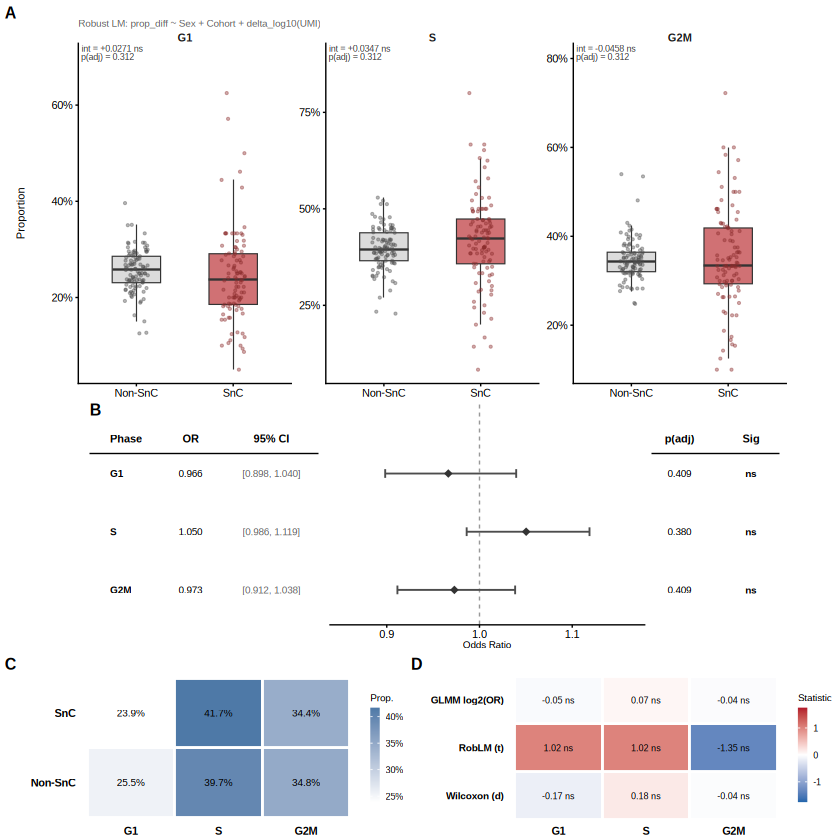

In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# MODULE 09 — STEP 4B: CELL CYCLE VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════════

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("MODULE 09 — STEP 4B: CELL CYCLE VISUALIZATION\n")
cat(paste(rep("=", 80), collapse = ""), "\n")

suppressPackageStartupMessages({
    library(ggplot2)
    library(patchwork)
    library(dplyr)
    library(tidyr)
    library(scales)
})

if (!exists("obj_ct")) stop("Run Step 1 first")
if (!exists("cc_donor_df")) stop("Run Step 4A first")
if (!exists("cc_rlm_df")) stop("Run Step 4A first — cc_rlm_df not found")
if (!exists("cc_cell_df")) stop("Run Step 4A first")

md <- obj_ct@meta.data

# ─────────────────────────────────────────────────────────────────────────────
# THEME & CONFIG
# ─────────────────────────────────────────────────────────────────────────────

TAG_SIZE <- 9

theme_pub <- theme_classic(base_size = 7) +
    theme(
        plot.title         = element_text(face = "bold", size = 7.5, margin = margin(0, 0, 2, 0)),
        plot.subtitle      = element_text(size = 5.5, color = "grey40", margin = margin(0, 0, 2, 0)),
        plot.margin        = margin(2, 2, 2, 2),
        plot.tag           = element_text(face = "bold", size = TAG_SIZE),
        strip.text         = element_text(face = "bold", size = 6.5, margin = margin(1, 0, 1, 0)),
        strip.background   = element_blank(),
        axis.title         = element_text(size = 6.5),
        axis.text          = element_text(size = 6),
        axis.line          = element_line(linewidth = 0.3),
        axis.ticks         = element_line(linewidth = 0.3),
        legend.title       = element_text(size = 5.5),
        legend.text        = element_text(size = 5),
        legend.key.size    = unit(0.25, "cm"),
        legend.margin      = margin(0, 0, 0, 0),
        legend.box.margin  = margin(0, 0, 0, 0)
    )

SEN_FILL   <- c("False" = "#D3D3D3", "True" = "#C44E52")
SEN_LABELS <- c("False" = "Non-SnC", "True" = "SnC")

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A: BOX PLOTS + JITTER (DONOR-LEVEL, ROBUST LM STATS)
# ─────────────────────────────────────────────────────────────────────────────

cat("\nPanel A: Box plots with jitter (Robust LM stats)\n")

cc_donor_long <- md %>%
    filter(.data[[DONOR_COL]] %in% paired_ids) %>%
    group_by(.data[[DONOR_COL]], .data[[SEN_COL]], Phase) %>%
    tally() %>%
    group_by(.data[[DONOR_COL]], .data[[SEN_COL]]) %>%
    mutate(prop = n / sum(n)) %>%
    ungroup() %>%
    mutate(
        sen_label = factor(.data[[SEN_COL]], levels = c("False", "True")),
        Phase     = factor(Phase, levels = c("G1", "S", "G2M"))
    )

# Use robust LM stats for annotation
stats_text <- cc_rlm_df %>%
    mutate(
        Phase = factor(Phase, levels = c("G1", "S", "G2M")),
        label = paste0(
            "int = ", sprintf("%+.4f", intercept), " ", sig, "\n",
            "p(adj) = ", ifelse(p_adj < 0.001, sprintf("%.1e", p_adj), sprintf("%.3f", p_adj))
        )
    )

p_box <- ggplot(cc_donor_long, aes(x = sen_label, y = prop, fill = sen_label)) +
    geom_boxplot(width = 0.5, outlier.shape = NA,
                 linewidth = 0.25, alpha = 0.8) +
    geom_jitter(aes(color = sen_label), width = 0.12, size = 0.4, alpha = 0.4,
                show.legend = FALSE) +
    scale_color_manual(values = c("False" = "grey30", "True" = "#8B2C2C")) +
    facet_wrap(~Phase, nrow = 1, scales = "free_y") +
    scale_fill_manual(values = SEN_FILL, labels = SEN_LABELS, name = NULL) +
    scale_x_discrete(labels = SEN_LABELS) +
    scale_y_continuous(labels = percent_format(accuracy = 1),
                       expand = expansion(mult = c(0.05, 0.18))) +
    geom_text(data = stats_text,
              aes(x = -Inf, y = Inf, label = label),
              inherit.aes = FALSE,
              hjust = -0.05, vjust = 1.1, size = 1.7, color = "grey25",
              lineheight = 0.85) +
    labs(x = NULL, y = "Proportion",
         subtitle = "Robust LM: prop_diff ~ Sex + Cohort + delta_log10(UMI)",
         tag = "A") +
    theme_pub +
    theme(legend.position = "none",
          panel.spacing   = unit(0.15, "cm"))

cat("  ✓ Box plot\n")

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B: TABLE-STYLE FOREST PLOT (GLMM)
# ─────────────────────────────────────────────────────────────────────────────

cat("Panel B: Table-style forest plot (GLMM)\n")

forest_df <- cc_cell_df %>%
    mutate(
        Phase     = factor(Phase, levels = rev(c("G1", "S", "G2M"))),
        y_pos     = as.numeric(Phase),
        or_label  = sprintf("%.3f", odds_ratio),
        ci_label  = sprintf("[%.3f, %.3f]", CI_lower, CI_upper),
        p_label   = ifelse(p_adj < 0.001, sprintf("%.1e", p_adj), sprintf("%.3f", p_adj)),
        sig_label = sig
    )

y_max <- max(forest_df$y_pos)

p_table_left <- ggplot(forest_df, aes(y = y_pos)) +
    geom_text(aes(x = 0, label = as.character(Phase)),
              size = 2, hjust = 0, fontface = "bold") +
    geom_text(aes(x = 1.2, label = or_label), size = 1.9, hjust = 0.5) +
    geom_text(aes(x = 2.4, label = ci_label), size = 1.9, hjust = 0.5, color = "grey40") +
    annotate("text", x = 0, y = y_max + 0.6, label = "Phase",
             size = 2.2, fontface = "bold", hjust = 0) +
    annotate("text", x = 1.2, y = y_max + 0.6, label = "OR",
             size = 2.2, fontface = "bold", hjust = 0.5) +
    annotate("text", x = 2.4, y = y_max + 0.6, label = "95% CI",
             size = 2.2, fontface = "bold", hjust = 0.5) +
    annotate("segment", x = -0.3, xend = 3.1,
             y = y_max + 0.35, yend = y_max + 0.35, linewidth = 0.3) +
    annotate("text", x = -0.3, y = y_max + 1.1, label = "B",
             size = TAG_SIZE / 2.845, fontface = "bold", hjust = 0) +
    scale_x_continuous(limits = c(-0.3, 3.1)) +
    scale_y_continuous(limits = c(0.4, y_max + 1.2), expand = c(0, 0)) +
    theme_void() +
    theme(plot.margin = margin(2, 0, 2, 2))

or_range <- range(c(forest_df$CI_lower, forest_df$CI_upper))
or_pad   <- diff(or_range) * 0.2
x_forest_min <- or_range[1] - or_pad
x_forest_max <- or_range[2] + or_pad

p_forest_main <- ggplot(forest_df, aes(x = odds_ratio, y = y_pos)) +
    geom_vline(xintercept = 1, linetype = "dashed", color = "grey60", linewidth = 0.3) +
    geom_errorbarh(aes(xmin = CI_lower, xmax = CI_upper),
                   height = 0.15, linewidth = 0.4, color = "grey30") +
    geom_point(size = 2.2, shape = 18, color = "grey20") +
    scale_x_continuous(
        limits = c(x_forest_min, x_forest_max),
        breaks = pretty_breaks(n = 4)
    ) +
    scale_y_continuous(limits = c(0.4, y_max + 1.2), expand = c(0, 0)) +
    labs(x = "Odds Ratio") +
    theme_pub +
    theme(
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank(),
        axis.title.y = element_blank(),
        axis.title.x = element_text(size = 5.5),
        panel.grid   = element_blank(),
        plot.margin  = margin(2, 0, 2, 0),
        plot.tag     = element_blank()
    )

p_table_right <- ggplot(forest_df, aes(y = y_pos)) +
    geom_text(aes(x = 0, label = p_label), size = 1.9, hjust = 0.5) +
    geom_text(aes(x = 1, label = sig_label), size = 1.9, hjust = 0.5, fontface = "bold") +
    annotate("text", x = 0, y = y_max + 0.6, label = "p(adj)",
             size = 2.2, fontface = "bold", hjust = 0.5) +
    annotate("text", x = 1, y = y_max + 0.6, label = "Sig",
             size = 2.2, fontface = "bold", hjust = 0.5) +
    annotate("segment", x = -0.4, xend = 1.4,
             y = y_max + 0.35, yend = y_max + 0.35, linewidth = 0.3) +
    scale_x_continuous(limits = c(-0.4, 1.4)) +
    scale_y_continuous(limits = c(0.4, y_max + 1.2), expand = c(0, 0)) +
    theme_void() +
    theme(plot.margin = margin(2, 2, 2, 0))

p_forest_combined <- p_table_left + p_forest_main + p_table_right +
    plot_layout(widths = c(0.32, 0.4, 0.18))

cat("  ✓ Forest plot\n")

# ─────────────────────────────────────────────────────────────────────────────
# PANEL C: HEATMAP — PHASE PROPORTIONS (SnC vs Non-SnC)
# ─────────────────────────────────────────────────────────────────────────────

cat("Panel C: Heatmap (proportions)\n")

heat_prop <- data.frame(
    Phase = factor(rep(c("G1", "S", "G2M"), 2), levels = c("G1", "S", "G2M")),
    Status = factor(rep(c("Non-SnC", "SnC"), each = 3), levels = c("Non-SnC", "SnC")),
    prop = c(
        cc_donor_df$mean_NonSnC[cc_donor_df$Phase == "G1"],
        cc_donor_df$mean_NonSnC[cc_donor_df$Phase == "S"],
        cc_donor_df$mean_NonSnC[cc_donor_df$Phase == "G2M"],
        cc_donor_df$mean_SnC[cc_donor_df$Phase == "G1"],
        cc_donor_df$mean_SnC[cc_donor_df$Phase == "S"],
        cc_donor_df$mean_SnC[cc_donor_df$Phase == "G2M"]
    )
)

heat_prop$label <- sprintf("%.1f%%", heat_prop$prop * 100)

p_heat_prop <- ggplot(heat_prop, aes(x = Phase, y = Status, fill = prop)) +
    geom_tile(color = "white", linewidth = 0.6) +
    geom_text(aes(label = label), size = 2, color = "black") +
    scale_fill_gradient(
        low = "white", high = "#4E79A7",
        labels = percent_format(accuracy = 1),
        name = "Prop."
    ) +
    labs(x = NULL, y = NULL, tag = "C") +
    theme_pub +
    theme(
        panel.grid        = element_blank(),
        axis.line         = element_blank(),
        axis.ticks        = element_blank(),
        axis.text.x       = element_text(face = "bold", size = 6),
        axis.text.y       = element_text(face = "bold", size = 6),
        legend.position   = "right",
        legend.key.height = unit(0.4, "cm"),
        legend.key.width  = unit(0.2, "cm")
    )

cat("  ✓ Heatmap (proportions)\n")

# ─────────────────────────────────────────────────────────────────────────────
# PANEL D: HEATMAP — EFFECT SIZES (3 TESTS)
# ─────────────────────────────────────────────────────────────────────────────

cat("Panel D: Heatmap (effect sizes — 3 tests)\n")

heat_effect <- data.frame(
    Phase = factor(rep(c("G1", "S", "G2M"), 3), levels = c("G1", "S", "G2M")),
    Test  = factor(rep(c("Wilcoxon (d)", "RobLM (t)", "GLMM log2(OR)"), each = 3),
                   levels = c("Wilcoxon (d)", "RobLM (t)", "GLMM log2(OR)")),
    value = c(
        cc_donor_df$cohens_d,
        cc_rlm_df$t_value,
        log2(cc_cell_df$odds_ratio)
    ),
    sig = c(cc_donor_df$sig, cc_rlm_df$sig, cc_cell_df$sig)
)

heat_effect$label <- sprintf("%.2f %s", heat_effect$value, heat_effect$sig)
eff_lim <- max(abs(heat_effect$value)) * 1.3

p_heat_effect <- ggplot(heat_effect, aes(x = Phase, y = Test, fill = value)) +
    geom_tile(color = "white", linewidth = 0.6) +
    geom_text(aes(label = label), size = 1.8) +
    scale_fill_gradient2(
        low = "#2166AC", mid = "white", high = "#B2182B",
        midpoint = 0, limits = c(-eff_lim, eff_lim),
        name = "Statistic"
    ) +
    labs(x = NULL, y = NULL, tag = "D") +
    theme_pub +
    theme(
        panel.grid        = element_blank(),
        axis.line         = element_blank(),
        axis.ticks        = element_blank(),
        axis.text.x       = element_text(face = "bold", size = 6),
        axis.text.y       = element_text(face = "bold", size = 5.5),
        legend.position   = "right",
        legend.key.height = unit(0.4, "cm"),
        legend.key.width  = unit(0.2, "cm")
    )

cat("  ✓ Heatmap (effect sizes)\n")

# ─────────────────────────────────────────────────────────────────────────────
# COMBINE & SAVE
# ─────────────────────────────────────────────────────────────────────────────

cat("\nSaving figures\n")

p_combined <- (p_box) /
              (p_forest_combined) /
              (p_heat_prop | p_heat_effect) +
    plot_layout(heights = c(1, 0.65, 0.45)) +
    plot_annotation(
        theme = theme(plot.margin = margin(1, 1, 1, 1))
    )

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_cell_cycle_boxplot.svg")),
       p_box, width = 3.2, height = 2.2, dpi = 300)
cat("  ✓", paste0(CELL_TYPE, "_cell_cycle_boxplot.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_cell_cycle_forest.svg")),
       p_forest_combined, width = 4, height = 1.8, dpi = 300)
cat("  ✓", paste0(CELL_TYPE, "_cell_cycle_forest.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_cell_cycle_heatmap_prop.svg")),
       p_heat_prop, width = 2.5, height = 1.2, dpi = 300)
cat("  ✓", paste0(CELL_TYPE, "_cell_cycle_heatmap_prop.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_cell_cycle_heatmap_effect.svg")),
       p_heat_effect, width = 3, height = 1.5, dpi = 300)
cat("  ✓", paste0(CELL_TYPE, "_cell_cycle_heatmap_effect.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_cell_cycle_combined.svg")),
       p_combined, width = 4.5, height = 5.5, dpi = 300)
cat("  ✓", paste0(CELL_TYPE, "_cell_cycle_combined.svg\n"))

print(p_combined)

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("STEP 4B COMPLETE\n")
cat(paste(rep("=", 80), collapse = ""), "\n")
cat("  Figures:", FIGURES_DIR, "\n")
cat(paste(rep("=", 80), collapse = ""), "\n")

In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# MODULE 09 — STEP 5A: MODULE SCORE ENRICHMENT TESTING
# ════════════════════════════════════════════════════════════════════════════════

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("MODULE 09 — STEP 5A: MODULE SCORE ENRICHMENT TESTING\n")
cat(paste(rep("=", 80), collapse = ""), "\n")

suppressPackageStartupMessages({
    library(dplyr)
    library(tidyr)
    library(lme4)
    library(lmerTest)
    library(robustbase)
})

select <- dplyr::select

if (!exists("obj_ct")) stop("Run Step 1 first")

md <- obj_ct@meta.data
score_cols <- grep("^Score_", colnames(md), value = TRUE)
cat("✓ Using obj_ct:", ncol(obj_ct), "cells\n")
cat("✓ Score columns:", length(score_cols), "\n")
cat("✓ Scores:", paste(sub("^Score_", "", score_cols), collapse = ", "), "\n")

MIN_CELLS_PER_GROUP <- 5

# ─────────────────────────────────────────────────────────────────────────────
# PART A: PSEUDO-BULK MODULE SCORES PER DONOR
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART A: Pseudo-bulk module scores per donor\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

donor_scores <- md %>%
    group_by(.data[[DONOR_COL]], .data[[SEN_COL]]) %>%
    summarise(
        n_cells = n(),
        across(all_of(score_cols), mean),
        .groups = "drop"
    )

n_before <- nrow(donor_scores)
donor_scores <- donor_scores %>% filter(n_cells >= MIN_CELLS_PER_GROUP)
cat("  Removed", n_before - nrow(donor_scores), "donor-status pairs with <",
    MIN_CELLS_PER_GROUP, "cells\n")

paired_ids <- donor_scores %>%
    group_by(.data[[DONOR_COL]]) %>%
    filter(n_distinct(.data[[SEN_COL]]) == 2) %>%
    pull(.data[[DONOR_COL]]) %>%
    unique()

n_paired <- length(paired_ids)
cat("  Paired donors (both groups >=", MIN_CELLS_PER_GROUP, "cells):", n_paired, "\n")

donor_scores_paired <- donor_scores %>%
    filter(.data[[DONOR_COL]] %in% paired_ids)

donor_wide <- donor_scores_paired %>%
    pivot_wider(
        id_cols     = all_of(DONOR_COL),
        names_from  = all_of(SEN_COL),
        values_from = c(n_cells, all_of(score_cols)),
        names_sep   = "_"
    )
cat("  Wide format:", nrow(donor_wide), "donors x", ncol(donor_wide), "columns\n")

cat("\n  Paired donor cell counts:\n")
snc_cells    <- donor_scores_paired %>% filter(.data[[SEN_COL]] == "True")
nonsnc_cells <- donor_scores_paired %>% filter(.data[[SEN_COL]] == "False")
cat(sprintf("    SnC:     median=%d, range=[%d, %d]\n",
            as.integer(median(snc_cells$n_cells)),
            min(snc_cells$n_cells), max(snc_cells$n_cells)))
cat(sprintf("    Non-SnC: median=%d, range=[%d, %d]\n",
            as.integer(median(nonsnc_cells$n_cells)),
            min(nonsnc_cells$n_cells), max(nonsnc_cells$n_cells)))

donor_meta <- md %>%
    filter(.data[[DONOR_COL]] %in% paired_ids) %>%
    group_by(.data[[DONOR_COL]]) %>%
    summarise(
        sex    = first(.data[[SEX_COL]]),
        cohort = first(.data[[COHORT_COL]]),
        .groups = "drop"
    )

donor_umi <- md %>%
    filter(.data[[DONOR_COL]] %in% paired_ids) %>%
    group_by(.data[[DONOR_COL]], .data[[SEN_COL]]) %>%
    summarise(mean_log10_umi = mean(log10(nCount_RNA)), .groups = "drop") %>%
    pivot_wider(
        id_cols     = all_of(DONOR_COL),
        names_from  = all_of(SEN_COL),
        values_from = mean_log10_umi,
        names_prefix = "umi_"
    ) %>%
    mutate(delta_log10_umi = umi_True - umi_False)

cat(sprintf("  Delta log10(UMI) (SnC - NonSnC): median=%.3f\n",
            median(donor_umi$delta_log10_umi)))

# ─────────────────────────────────────────────────────────────────────────────
# PART B: PAIRED WILCOXON SIGNED-RANK TESTS (UNADJUSTED)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART B: Paired Wilcoxon signed-rank tests (unadjusted)\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

list_names <- sub("^Score_", "", score_cols)

wilcox_results <- list()

for (k in seq_along(score_cols)) {
    sc    <- score_cols[k]
    lname <- list_names[k]

    score_wide <- donor_scores_paired %>%
        dplyr::select(all_of(DONOR_COL), all_of(SEN_COL), all_of(sc)) %>%
        pivot_wider(
            id_cols     = all_of(DONOR_COL),
            names_from  = all_of(SEN_COL),
            values_from = all_of(sc)
        )

    snc_vals    <- score_wide$`True`
    nonsnc_vals <- score_wide$`False`
    diff_vals   <- snc_vals - nonsnc_vals

    wt <- wilcox.test(snc_vals, nonsnc_vals, paired = TRUE,
                      exact = FALSE, conf.int = TRUE)

    d_val      <- mean(diff_vals) / sd(diff_vals)
    pct_higher <- mean(diff_vals > 0) * 100

    n_obs  <- sum(diff_vals != 0)
    W_stat <- as.numeric(wt$statistic)
    W_max  <- n_obs * (n_obs + 1) / 2
    r_rb   <- (2 * W_stat / W_max) - 1

    wilcox_results[[lname]] <- data.frame(
        Gene_List         = lname,
        test              = "Paired Wilcoxon (unadjusted)",
        n_paired_donors   = n_paired,
        n_genes           = length(gene_lists[[lname]]),
        mean_SnC          = mean(snc_vals),
        mean_NonSnC       = mean(nonsnc_vals),
        mean_diff         = mean(diff_vals),
        cohens_d          = d_val,
        rank_biserial_r   = r_rb,
        pct_donors_higher = pct_higher,
        HL_estimate       = as.numeric(wt$estimate),
        statistic         = W_stat,
        p_value           = wt$p.value,
        stringsAsFactors  = FALSE
    )
}

wilcox_df <- bind_rows(wilcox_results)
wilcox_df$p_adj <- p.adjust(wilcox_df$p_value, method = "BH")
wilcox_df$sig <- ifelse(wilcox_df$p_adj < 0.001, "***",
                 ifelse(wilcox_df$p_adj < 0.01, "**",
                 ifelse(wilcox_df$p_adj < 0.05, "*", "ns")))

wilcox_df <- wilcox_df %>% arrange(desc(abs(cohens_d)))

cat("\n  PAIRED WILCOXON (UNADJUSTED):\n")
cat(sprintf("  %-22s %9s %8s %8s %6s %8s %8s %4s\n",
            "List", "MeanDiff", "Cohen d", "r_rb", "% Up", "p_raw", "p_adj", "Sig"))
cat("  ", paste(rep("-", 78), collapse = ""), "\n")

for (i in seq_len(nrow(wilcox_df))) {
    r <- wilcox_df[i, ]
    cat(sprintf("  %-22s %+9.4f %8.3f %8.3f %5.1f%% %8.1e %8.1e %4s\n",
                r$Gene_List, r$mean_diff, r$cohens_d, r$rank_biserial_r,
                r$pct_donors_higher, r$p_value, r$p_adj, r$sig))
}

donor_df <- wilcox_df

# ─────────────────────────────────────────────────────────────────────────────
# PART B2: ROBUST LINEAR REGRESSION ON PAIRED DIFFERENCES (ADJUSTED)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART B2: Robust linear regression on paired differences (adjusted)\n")
cat("  Model: score_diff ~ Sex + Cohort + delta_log10_UMI\n")
cat("  Method: robustbase::lmrob (MM-estimator)\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

rlm_results <- list()

for (k in seq_along(score_cols)) {
    sc    <- score_cols[k]
    lname <- list_names[k]

    score_wide <- donor_scores_paired %>%
        dplyr::select(all_of(DONOR_COL), all_of(SEN_COL), all_of(sc)) %>%
        pivot_wider(
            id_cols     = all_of(DONOR_COL),
            names_from  = all_of(SEN_COL),
            values_from = all_of(sc)
        )

    reg_df <- score_wide %>%
        mutate(diff = `True` - `False`) %>%
        left_join(donor_meta, by = DONOR_COL) %>%
        left_join(donor_umi, by = DONOR_COL) %>%
        mutate(
            sex    = as.factor(sex),
            cohort = as.factor(cohort)
        )

    cat(sprintf("  Fitting %-22s", lname))

    fit <- tryCatch({
        lmrob(diff ~ sex + cohort + delta_log10_umi, data = reg_df,
              setting = "KS2014")
    }, error = function(e) {
        cat(sprintf(" ERROR: %s\n", e$message))
        return(NULL)
    })

    if (is.null(fit)) next

    coefs <- summary(fit)$coefficients

    int_est <- coefs["(Intercept)", "Estimate"]
    int_se  <- coefs["(Intercept)", "Std. Error"]
    int_t   <- coefs["(Intercept)", "t value"]
    int_p   <- coefs["(Intercept)", "Pr(>|t|)"]

    cat(sprintf(" Int=%+.4f, t=%.2f, p=%.2e", int_est, int_t, int_p))

    weights <- fit$rweights
    n_dw <- sum(weights < 0.9)
    cat(sprintf("  [dw=%d/%d]\n", n_dw, nrow(reg_df)))

    cat("    Full model:\n")
    for (j in seq_len(nrow(coefs))) {
        cat(sprintf("      %-25s beta=%+.4f  t=%+.2f  p=%.2e\n",
                    rownames(coefs)[j],
                    coefs[j, "Estimate"],
                    coefs[j, "t value"],
                    coefs[j, "Pr(>|t|)"]))
    }

    rlm_results[[lname]] <- data.frame(
        Gene_List      = lname,
        test           = "Robust LM (lmrob MM, adjusted)",
        n_donors       = nrow(reg_df),
        intercept      = int_est,
        SE             = int_se,
        CI_lower       = int_est - qt(0.975, df = fit$df.residual) * int_se,
        CI_upper       = int_est + qt(0.975, df = fit$df.residual) * int_se,
        t_value        = int_t,
        df_residual    = fit$df.residual,
        p_value        = int_p,
        r_squared      = summary(fit)$r.squared,
        n_downweighted = n_dw,
        covariates     = "Sex + Cohort + delta_log10_UMI",
        stringsAsFactors = FALSE
    )
}

rlm_df <- bind_rows(rlm_results)
rlm_df$p_adj <- p.adjust(rlm_df$p_value, method = "BH")
rlm_df$sig <- ifelse(rlm_df$p_adj < 0.001, "***",
              ifelse(rlm_df$p_adj < 0.01, "**",
              ifelse(rlm_df$p_adj < 0.05, "*", "ns")))

rlm_df <- rlm_df %>% arrange(desc(abs(t_value)))

cat("\n  ROBUST LM (ADJUSTED DONOR-LEVEL):\n")
cat(sprintf("  %-22s %10s %8s %20s %8s %8s %8s %4s\n",
            "List", "Intercept", "SE", "95% CI", "t", "p_raw", "p_adj", "Sig"))
cat("  ", paste(rep("-", 88), collapse = ""), "\n")

for (i in seq_len(nrow(rlm_df))) {
    r <- rlm_df[i, ]
    cat(sprintf("  %-22s %+10.4f %8.4f [%+.4f, %+.4f] %8.2f %8.1e %8.1e %4s\n",
                r$Gene_List, r$intercept, r$SE, r$CI_lower, r$CI_upper,
                r$t_value, r$p_value, r$p_adj, r$sig))
}

# ─────────────────────────────────────────────────────────────────────────────
# PART C: CELL-LEVEL LMM (LINEAR MIXED MODEL)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART C: Cell-level LMM (linear mixed model)\n")
cat("  Model: score ~ is_senescent + Sex + Cohort + log10(nCount_RNA) + (1|donor)\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

cell_df <- md %>%
    filter(.data[[DONOR_COL]] %in% paired_ids) %>%
    mutate(
        is_senescent = as.factor(.data[[SEN_COL]]),
        donor        = as.factor(.data[[DONOR_COL]]),
        sex          = as.factor(.data[[SEX_COL]]),
        cohort       = as.factor(.data[[COHORT_COL]]),
        log10_nCount = log10(nCount_RNA)
    )

cat("  Cells in paired donors:", nrow(cell_df), "\n")
cat("  Covariates: Sex + Cohort + log10(nCount_RNA)\n")

cell_results <- list()

for (k in seq_along(score_cols)) {
    sc    <- score_cols[k]
    lname <- list_names[k]

    cat(sprintf("  Fitting %-22s", lname))

    formula_str <- paste0("`", sc, "` ~ is_senescent + sex + cohort + log10_nCount + (1|donor)")

    fit <- tryCatch({
        lmer(as.formula(formula_str),
             data    = cell_df,
             REML    = TRUE,
             control = lmerControl(optimizer = "bobyqa",
                                   optCtrl = list(maxfun = 100000)))
    }, error = function(e) {
        cat(sprintf(" ERROR: %s\n", e$message))
        return(NULL)
    })

    if (is.null(fit)) next

    coef_tbl <- summary(fit)$coefficients
    sen_row  <- grep("is_senescent", rownames(coef_tbl))
    estimate <- coef_tbl[sen_row, "Estimate"]
    se       <- coef_tbl[sen_row, "Std. Error"]
    t_val    <- coef_tbl[sen_row, "t value"]

    p_val <- tryCatch({
        coef_tbl[sen_row, "Pr(>|t|)"]
    }, error = function(e) {
        2 * pt(abs(t_val), df = summary(fit)$coefficients[sen_row, "df"], lower.tail = FALSE)
    })

    cat(sprintf(" beta=%+.4f, SE=%.4f, t=%.2f, p=%.2e\n",
                estimate, se, t_val, p_val))

    all_coefs <- as.data.frame(coef_tbl)
    all_coefs$term <- rownames(all_coefs)
    cat("    Full model:\n")
    for (j in seq_len(nrow(all_coefs))) {
        cat(sprintf("      %-25s beta=%+.4f  t=%+.2f  p=%.2e\n",
                    all_coefs$term[j],
                    all_coefs$Estimate[j],
                    all_coefs$`t value`[j],
                    all_coefs$`Pr(>|t|)`[j]))
    }

    cell_results[[lname]] <- data.frame(
        Gene_List  = lname,
        test       = "LMM (cell-level, adjusted)",
        n_cells    = nrow(cell_df),
        n_donors   = n_paired,
        estimate   = estimate,
        SE         = se,
        CI_lower   = estimate - 1.96 * se,
        CI_upper   = estimate + 1.96 * se,
        t_value    = t_val,
        p_value    = p_val,
        covariates = "Sex + Cohort + log10(nCount_RNA)",
        stringsAsFactors = FALSE
    )
}

cell_df_results <- bind_rows(cell_results)
cell_df_results$p_adj <- p.adjust(cell_df_results$p_value, method = "BH")
cell_df_results$sig <- ifelse(cell_df_results$p_adj < 0.001, "***",
                       ifelse(cell_df_results$p_adj < 0.01, "**",
                       ifelse(cell_df_results$p_adj < 0.05, "*", "ns")))

cell_df_results <- cell_df_results %>% arrange(desc(abs(t_value)))

cat("\n  CELL-LEVEL LMM RESULTS:\n")
cat(sprintf("  %-22s %9s %8s %20s %8s %8s %8s %4s\n",
            "List", "Estimate", "SE", "95% CI", "t", "p_raw", "p_adj", "Sig"))
cat("  ", paste(rep("-", 88), collapse = ""), "\n")

for (i in seq_len(nrow(cell_df_results))) {
    r <- cell_df_results[i, ]
    cat(sprintf("  %-22s %+9.4f %8.4f [%+.4f,%+.4f] %8.2f %8.1e %8.1e %4s\n",
                r$Gene_List, r$estimate, r$SE, r$CI_lower, r$CI_upper,
                r$t_value, r$p_value, r$p_adj, r$sig))
}

# ─────────────────────────────────────────────────────────────────────────────
# PART D: COMBINED SUMMARY (3 TESTS)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART D: Combined summary (3 tests)\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

list_order <- c("p53_Targets", "CellCycleArrest", "SASP", "AntiApoptosis",
                "DDR", "CellSurfaceMarkers", "LysosomalContent",
                "SD_TMC", "SenMayo", "Fridman_Up")

wilcox_aligned <- wilcox_df %>% arrange(match(Gene_List, list_order))
rlm_aligned    <- rlm_df %>% arrange(match(Gene_List, list_order))
cell_aligned   <- cell_df_results %>% arrange(match(Gene_List, list_order))

cat("\n")
cat(sprintf("  %-22s %5s | %8s %4s | %10s %4s | %9s %4s\n",
            "List", "Genes",
            "Wilcox p", "Sig",
            "RobLM p", "Sig",
            "LMM p", "Sig"))
cat("  ", paste(rep("-", 80), collapse = ""), "\n")

for (i in seq_len(nrow(wilcox_aligned))) {
    cat(sprintf("  %-22s %5d | %8.1e %4s | %10.1e %4s | %9.1e %4s\n",
                wilcox_aligned$Gene_List[i],
                wilcox_aligned$n_genes[i],
                wilcox_aligned$p_adj[i], wilcox_aligned$sig[i],
                rlm_aligned$p_adj[i], rlm_aligned$sig[i],
                cell_aligned$p_adj[i], cell_aligned$sig[i]))
}

cat("\n  Tests:\n")
cat("    Wilcoxon: Paired signed-rank on pseudo-bulked scores (unadjusted)\n")
cat("    RobLM:    Robust LM on paired diffs ~ Sex + Cohort + delta_log10_UMI\n")
cat("    LMM:      score ~ is_senescent + Sex + Cohort + log10(UMI) + (1|donor)\n")
cat("    Positive diff/beta/intercept: SnC scores higher than Non-SnC\n")

# ─────────────────────────────────────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("Saving results\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

write.csv(wilcox_df,
          file.path(RESULTS_DIR, paste0(CELL_TYPE, "_module_score_wilcox_tests.csv")),
          row.names = FALSE)
cat("  ✓", paste0(CELL_TYPE, "_module_score_wilcox_tests.csv\n"))

write.csv(rlm_df,
          file.path(RESULTS_DIR, paste0(CELL_TYPE, "_module_score_rlm_tests.csv")),
          row.names = FALSE)
cat("  ✓", paste0(CELL_TYPE, "_module_score_rlm_tests.csv\n"))

write.csv(cell_df_results,
          file.path(RESULTS_DIR, paste0(CELL_TYPE, "_module_score_cell_tests.csv")),
          row.names = FALSE)
cat("  ✓", paste0(CELL_TYPE, "_module_score_cell_tests.csv\n"))

write.csv(donor_wide,
          file.path(RESULTS_DIR, paste0(CELL_TYPE, "_donor_scores_wide.csv")),
          row.names = FALSE)
cat("  ✓", paste0(CELL_TYPE, "_donor_scores_wide.csv\n"))

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("STEP 5A COMPLETE — Ready for Step 5B (visualization)\n")
cat(paste(rep("=", 80), collapse = ""), "\n")
cat("  Paired donors:          ", n_paired, "\n")
cat("  Wilcoxon sig (FDR):     ", sum(wilcox_df$p_adj < 0.05), "/", nrow(wilcox_df), "\n")
cat("  Robust LM sig (FDR):    ", sum(rlm_df$p_adj < 0.05), "/", nrow(rlm_df), "\n")
cat("  Cell LMM sig (FDR):     ", sum(cell_df_results$p_adj < 0.05), "/", nrow(cell_df_results), "\n")
cat("  Covariates (RobLM):     Sex + Cohort + delta_log10_UMI\n")
cat("  Covariates (LMM):       Sex + Cohort + log10(nCount_RNA)\n")
cat("  Results:                ", RESULTS_DIR, "\n")
cat(paste(rep("=", 80), collapse = ""), "\n")


MODULE 09 — STEP 5A: MODULE SCORE ENRICHMENT TESTING
✓ Using obj_ct: 63658 cells
✓ Score columns: 10 
✓ Scores: p53_Targets, CellCycleArrest, SASP, AntiApoptosis, DDR, CellSurfaceMarkers, LysosomalContent, SD_TMC, SenMayo, Fridman_Up 

 ------------------------------------------------------------ 
PART A: Pseudo-bulk module scores per donor
------------------------------------------------------------ 
  Removed 18 donor-status pairs with < 5 cells
  Paired donors (both groups >= 5 cells): 101 
  Wide format: 101 donors x 23 columns

  Paired donor cell counts:
    SnC:     median=28, range=[5, 318]
    Non-SnC: median=420, range=[71, 1998]
  Delta log10(UMI) (SnC - NonSnC): median=0.221

 ------------------------------------------------------------ 
PART B: Paired Wilcoxon signed-rank tests (unadjusted)
------------------------------------------------------------ 

  PAIRED WILCOXON (UNADJUSTED):
  List                    MeanDiff  Cohen d     r_rb   % Up    p_raw    p_adj  Sig
   ---


MODULE 09 — STEP 5B: MODULE SCORE VISUALIZATION

Panel A: Box plots with jitter
  ✓ Box plot
Panel B: Table-style forest plot (LMM)
  ✓ Forest plot
Panel C: Heatmap (mean scores)
  ✓ Heatmap (scores)
Panel D: Heatmap (effect sizes — 3 tests)
  ✓ Heatmap (effect sizes)

Saving figures
  ✓ astrocyte_module_score_boxplot.svg


`height` was translated to `width`.


  ✓ astrocyte_module_score_forest.svg
  ✓ astrocyte_module_score_heatmap_scores.svg
  ✓ astrocyte_module_score_heatmap_effect.svg


`height` was translated to `width`.


  ✓ astrocyte_module_score_combined.svg


`height` was translated to `width`.



STEP 5B COMPLETE
  Figures: /fs/scratch/PAS2598/senescence_analysis/figures/09_senescence_enrichment/psychad_aging/astrocyte 


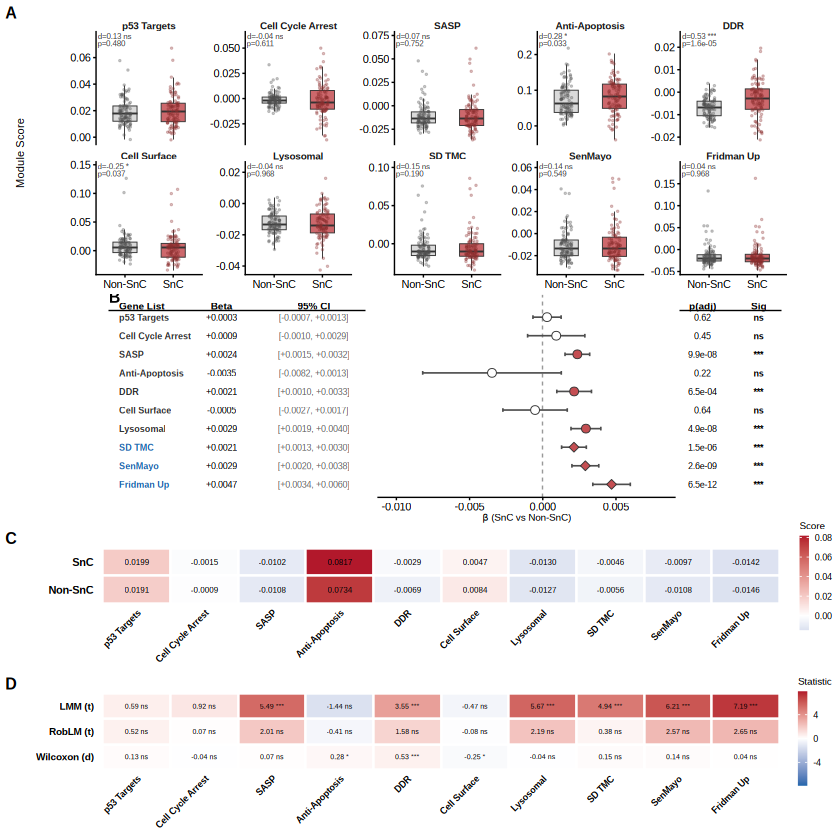

In [8]:
# ════════════════════════════════════════════════════════════════════════════════
# MODULE 09 — STEP 5B: MODULE SCORE VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════════

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("MODULE 09 — STEP 5B: MODULE SCORE VISUALIZATION\n")
cat(paste(rep("=", 80), collapse = ""), "\n")

suppressPackageStartupMessages({
    library(ggplot2)
    library(patchwork)
    library(dplyr)
    library(tidyr)
    library(scales)
})

select <- dplyr::select

if (!exists("obj_ct")) stop("Run Step 1 first")
if (!exists("donor_df")) stop("Run Step 5A first — donor_df not found")
if (!exists("rlm_df")) stop("Run Step 5A first — rlm_df not found")
if (!exists("cell_df_results")) stop("Run Step 5A first — cell_df_results not found")

md <- obj_ct@meta.data
score_cols <- grep("^Score_", colnames(md), value = TRUE)

# ─────────────────────────────────────────────────────────────────────────────
# THEME & CONFIG
# ─────────────────────────────────────────────────────────────────────────────

TAG_SIZE <- 9

theme_pub <- theme_classic(base_size = 7) +
    theme(
        plot.title         = element_text(face = "bold", size = 7.5, margin = margin(0, 0, 2, 0)),
        plot.subtitle      = element_text(size = 5.5, color = "grey40", margin = margin(0, 0, 2, 0)),
        plot.margin        = margin(2, 2, 2, 2),
        plot.tag           = element_text(face = "bold", size = TAG_SIZE),
        strip.text         = element_text(face = "bold", size = 5.5, margin = margin(1, 0, 1, 0)),
        strip.background   = element_blank(),
        axis.title         = element_text(size = 6.5),
        axis.text          = element_text(size = 6),
        axis.line          = element_line(linewidth = 0.3),
        axis.ticks         = element_line(linewidth = 0.3),
        legend.title       = element_text(size = 5.5),
        legend.text        = element_text(size = 5),
        legend.key.size    = unit(0.25, "cm"),
        legend.margin      = margin(0, 0, 0, 0),
        legend.box.margin  = margin(0, 0, 0, 0)
    )

SEN_FILL   <- c("False" = "#D3D3D3", "True" = "#C44E52")
SEN_LABELS <- c("False" = "Non-SnC", "True" = "SnC")

list_order <- c("p53_Targets", "CellCycleArrest", "SASP", "AntiApoptosis",
                "DDR", "CellSurfaceMarkers", "LysosomalContent",
                "SD_TMC", "SenMayo", "Fridman_Up")

list_labels <- c(
    "p53_Targets" = "p53 Targets", "CellCycleArrest" = "Cell Cycle Arrest",
    "SASP" = "SASP", "AntiApoptosis" = "Anti-Apoptosis",
    "DDR" = "DDR", "CellSurfaceMarkers" = "Cell Surface",
    "LysosomalContent" = "Lysosomal", "SD_TMC" = "SD TMC",
    "SenMayo" = "SenMayo", "Fridman_Up" = "Fridman Up"
)

list_types <- c(
    "p53_Targets" = "Individual", "CellCycleArrest" = "Individual",
    "SASP" = "Individual", "AntiApoptosis" = "Individual",
    "DDR" = "Individual", "CellSurfaceMarkers" = "Individual",
    "LysosomalContent" = "Individual",
    "SD_TMC" = "Multi-hallmark", "SenMayo" = "Multi-hallmark",
    "Fridman_Up" = "Multi-hallmark"
)

# ─────────────────────────────────────────────────────────────────────────────
# PANEL A: BOX PLOTS + JITTER
# ─────────────────────────────────────────────────────────────────────────────

cat("\nPanel A: Box plots with jitter\n")

donor_long <- md %>%
    filter(.data[[DONOR_COL]] %in% paired_ids) %>%
    group_by(.data[[DONOR_COL]], .data[[SEN_COL]]) %>%
    summarise(across(all_of(score_cols), mean), .groups = "drop") %>%
    pivot_longer(cols = all_of(score_cols), names_to = "list_name", values_to = "score") %>%
    mutate(
        list_name = sub("^Score_", "", list_name),
        list_name = factor(list_name, levels = list_order, labels = list_labels[list_order]),
        sen_label = factor(.data[[SEN_COL]], levels = c("False", "True"))
    )

stats_box <- donor_df %>%
    mutate(
        list_name = factor(Gene_List, levels = list_order, labels = list_labels[list_order]),
        label = paste0(
            "d=", sprintf("%.2f", cohens_d), " ", sig, "\n",
            "p=", ifelse(p_adj < 0.001, sprintf("%.1e", p_adj), sprintf("%.3f", p_adj))
        )
    )

p_box <- ggplot(donor_long, aes(x = sen_label, y = score, fill = sen_label)) +
    geom_boxplot(width = 0.5, outlier.shape = NA, linewidth = 0.2, alpha = 0.85) +
    geom_jitter(aes(color = sen_label), width = 0.12, size = 0.2, alpha = 0.3,
                show.legend = FALSE) +
    scale_color_manual(values = c("False" = "grey30", "True" = "#8B2C2C")) +
    facet_wrap(~list_name, nrow = 2, scales = "free_y") +
    scale_fill_manual(values = SEN_FILL, labels = SEN_LABELS, name = NULL) +
    scale_x_discrete(labels = SEN_LABELS) +
    scale_y_continuous(expand = expansion(mult = c(0.05, 0.18))) +
    geom_text(data = stats_box,
              aes(x = -Inf, y = Inf, label = label),
              inherit.aes = FALSE,
              hjust = -0.05, vjust = 1.1, size = 1.5, color = "grey25",
              lineheight = 0.85) +
    labs(x = NULL, y = "Module Score", tag = "A") +
    theme_pub +
    theme(legend.position = "none",
          panel.spacing   = unit(0.12, "cm"))

cat("  ✓ Box plot\n")

# ─────────────────────────────────────────────────────────────────────────────
# PANEL B: TABLE-STYLE FOREST PLOT — LMM (CELL-LEVEL)
# ─────────────────────────────────────────────────────────────────────────────

cat("Panel B: Table-style forest plot (LMM)\n")

forest_df <- cell_df_results %>%
    mutate(
        display = list_labels[Gene_List],
        display = factor(display, levels = rev(list_labels[list_order])),
        y_pos   = as.numeric(display),
        beta_label = sprintf("%+.4f", estimate),
        ci_label   = sprintf("[%+.4f, %+.4f]", CI_lower, CI_upper),
        p_label    = ifelse(p_adj < 0.001, sprintf("%.1e", p_adj),
                     ifelse(p_adj < 0.01, sprintf("%.3f", p_adj),
                            sprintf("%.2f", p_adj))),
        sig_label  = sig,
        type_label = list_types[Gene_List]
    )

type_colors <- c("Individual" = "grey20", "Multi-hallmark" = "#2166AC")
y_max <- max(forest_df$y_pos)

# --- Left table ---
p_table_left <- ggplot(forest_df, aes(y = y_pos)) +
    geom_text(aes(x = 0, label = as.character(display), color = type_label),
              size = 1.8, hjust = 0, fontface = "bold", show.legend = FALSE) +
    scale_color_manual(values = type_colors) +
    geom_text(aes(x = 2.0, label = beta_label), size = 1.7, hjust = 0.5) +
    geom_text(aes(x = 3.8, label = ci_label), size = 1.7, hjust = 0.5, color = "grey40") +
    annotate("text", x = 0, y = y_max + 0.6, label = "Gene List",
             size = 2, fontface = "bold", hjust = 0) +
    annotate("text", x = 2.0, y = y_max + 0.6, label = "Beta",
             size = 2, fontface = "bold", hjust = 0.5) +
    annotate("text", x = 3.8, y = y_max + 0.6, label = "95% CI",
             size = 2, fontface = "bold", hjust = 0.5) +
    annotate("segment", x = -0.2, xend = 4.8,
             y = y_max + 0.35, yend = y_max + 0.35, linewidth = 0.3) +
    annotate("text", x = -0.2, y = y_max + 1.1, label = "B",
             size = TAG_SIZE / 2.845, fontface = "bold", hjust = 0) +
    scale_x_continuous(limits = c(-0.2, 4.8)) +
    scale_y_continuous(limits = c(0.3, y_max + 1.2), expand = c(0, 0)) +
    theme_void() +
    theme(plot.margin = margin(2, 0, 2, 2))

# --- Forest graphic ---
ci_range <- range(c(forest_df$CI_lower, forest_df$CI_upper))
ci_pad   <- diff(ci_range) * 0.15
x_f_min  <- ci_range[1] - ci_pad
x_f_max  <- ci_range[2] + ci_pad

p_forest_main <- ggplot(forest_df, aes(x = estimate, y = y_pos)) +
    geom_vline(xintercept = 0, linetype = "dashed", color = "grey60", linewidth = 0.3) +
    geom_errorbarh(aes(xmin = CI_lower, xmax = CI_upper),
                   height = 0.2, linewidth = 0.35, color = "grey30") +
    geom_point(aes(shape = type_label, fill = ifelse(p_adj < 0.05, "sig", "ns")),
               size = 2, color = "grey20", stroke = 0.3) +
    scale_shape_manual(values = c("Individual" = 21, "Multi-hallmark" = 23), guide = "none") +
    scale_fill_manual(values = c("sig" = "#C44E52", "ns" = "white"), guide = "none") +
    scale_x_continuous(
        limits = c(x_f_min, x_f_max),
        breaks = pretty_breaks(n = 5)
    ) +
    scale_y_continuous(limits = c(0.3, y_max + 1.2), expand = c(0, 0)) +
    labs(x = expression(beta ~ "(SnC vs Non-SnC)")) +
    theme_pub +
    theme(
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank(),
        axis.title.y = element_blank(),
        axis.title.x = element_text(size = 5.5),
        panel.grid   = element_blank(),
        plot.margin  = margin(2, 0, 2, 0),
        plot.tag     = element_blank()
    )

# --- Right table ---
p_table_right <- ggplot(forest_df, aes(y = y_pos)) +
    geom_text(aes(x = 0, label = p_label), size = 1.7, hjust = 0.5) +
    geom_text(aes(x = 1, label = sig_label), size = 1.7, hjust = 0.5, fontface = "bold") +
    annotate("text", x = 0, y = y_max + 0.6, label = "p(adj)",
             size = 2, fontface = "bold", hjust = 0.5) +
    annotate("text", x = 1, y = y_max + 0.6, label = "Sig",
             size = 2, fontface = "bold", hjust = 0.5) +
    annotate("segment", x = -0.4, xend = 1.4,
             y = y_max + 0.35, yend = y_max + 0.35, linewidth = 0.3) +
    scale_x_continuous(limits = c(-0.4, 1.4)) +
    scale_y_continuous(limits = c(0.3, y_max + 1.2), expand = c(0, 0)) +
    theme_void() +
    theme(plot.margin = margin(2, 2, 2, 0))

p_forest_combined <- p_table_left + p_forest_main + p_table_right +
    plot_layout(widths = c(0.38, 0.4, 0.15))

cat("  ✓ Forest plot\n")

# ─────────────────────────────────────────────────────────────────────────────
# PANEL C: HEATMAP — MEAN SCORES (SnC vs Non-SnC)
# ─────────────────────────────────────────────────────────────────────────────

cat("Panel C: Heatmap (mean scores)\n")

wilcox_aligned <- donor_df %>% arrange(match(Gene_List, list_order))

heat_scores <- wilcox_aligned %>%
    dplyr::select(Gene_List, mean_SnC, mean_NonSnC) %>%
    pivot_longer(cols = c(mean_SnC, mean_NonSnC), names_to = "Status", values_to = "score") %>%
    mutate(
        Status    = factor(ifelse(Status == "mean_SnC", "SnC", "Non-SnC"),
                           levels = c("Non-SnC", "SnC")),
        Gene_List = factor(Gene_List, levels = list_order, labels = list_labels[list_order]),
        label     = sprintf("%.4f", score)
    )

p_heat_scores <- ggplot(heat_scores, aes(x = Gene_List, y = Status, fill = score)) +
    geom_tile(color = "white", linewidth = 0.5) +
    geom_text(aes(label = label), size = 1.6) +
    scale_fill_gradient2(
        low = "#2166AC", mid = "white", high = "#B2182B",
        midpoint = 0, name = "Score"
    ) +
    labs(x = NULL, y = NULL, tag = "C") +
    theme_pub +
    theme(
        panel.grid        = element_blank(),
        axis.line         = element_blank(),
        axis.ticks        = element_blank(),
        axis.text.x       = element_text(face = "bold", size = 5, angle = 45, hjust = 1),
        axis.text.y       = element_text(face = "bold", size = 6),
        legend.position   = "right",
        legend.key.height = unit(0.4, "cm"),
        legend.key.width  = unit(0.2, "cm")
    )

cat("  ✓ Heatmap (scores)\n")

# ─────────────────────────────────────────────────────────────────────────────
# PANEL D: HEATMAP — EFFECT SIZES (3 TESTS)
# ─────────────────────────────────────────────────────────────────────────────

cat("Panel D: Heatmap (effect sizes — 3 tests)\n")

rlm_aligned  <- rlm_df %>% arrange(match(Gene_List, list_order))
cell_aligned <- cell_df_results %>% arrange(match(Gene_List, list_order))

heat_effect <- data.frame(
    Gene_List = factor(rep(list_order, 3), levels = list_order, labels = list_labels[list_order]),
    Test  = factor(rep(c("Wilcoxon (d)", "RobLM (t)", "LMM (t)"), each = 10),
                   levels = c("Wilcoxon (d)", "RobLM (t)", "LMM (t)")),
    value = c(
        wilcox_aligned$cohens_d,
        rlm_aligned$t_value,
        cell_aligned$t_value
    ),
    sig = c(wilcox_aligned$sig, rlm_aligned$sig, cell_aligned$sig)
)

heat_effect$label <- sprintf("%.2f %s", heat_effect$value, heat_effect$sig)
eff_lim <- max(abs(heat_effect$value)) * 1.1

p_heat_effect <- ggplot(heat_effect, aes(x = Gene_List, y = Test, fill = value)) +
    geom_tile(color = "white", linewidth = 0.5) +
    geom_text(aes(label = label), size = 1.4) +
    scale_fill_gradient2(
        low = "#2166AC", mid = "white", high = "#B2182B",
        midpoint = 0, limits = c(-eff_lim, eff_lim),
        name = "Statistic"
    ) +
    labs(x = NULL, y = NULL, tag = "D") +
    theme_pub +
    theme(
        panel.grid        = element_blank(),
        axis.line         = element_blank(),
        axis.ticks        = element_blank(),
        axis.text.x       = element_text(face = "bold", size = 5, angle = 45, hjust = 1),
        axis.text.y       = element_text(face = "bold", size = 5.5),
        legend.position   = "right",
        legend.key.height = unit(0.4, "cm"),
        legend.key.width  = unit(0.2, "cm")
    )

cat("  ✓ Heatmap (effect sizes)\n")

# ─────────────────────────────────────────────────────────────────────────────
# COMBINE & SAVE
# ─────────────────────────────────────────────────────────────────────────────

cat("\nSaving figures\n")

p_combined <- (p_box) /
              (p_forest_combined) /
              (p_heat_scores) /
              (p_heat_effect) +
    plot_layout(heights = c(1.2, 1, 0.3, 0.4)) +
    plot_annotation(
        theme = theme(plot.margin = margin(1, 1, 1, 1))
    )

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_module_score_boxplot.svg")),
       p_box, width = 5.5, height = 3.5, dpi = 300)
cat("  ✓", paste0(CELL_TYPE, "_module_score_boxplot.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_module_score_forest.svg")),
       p_forest_combined, width = 5.5, height = 3, dpi = 300)
cat("  ✓", paste0(CELL_TYPE, "_module_score_forest.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_module_score_heatmap_scores.svg")),
       p_heat_scores, width = 5, height = 1.5, dpi = 300)
cat("  ✓", paste0(CELL_TYPE, "_module_score_heatmap_scores.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_module_score_heatmap_effect.svg")),
       p_heat_effect, width = 5.5, height = 1.8, dpi = 300)
cat("  ✓", paste0(CELL_TYPE, "_module_score_heatmap_effect.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_module_score_combined.svg")),
       p_combined, width = 6, height = 11, dpi = 300)
cat("  ✓", paste0(CELL_TYPE, "_module_score_combined.svg\n"))

print(p_combined)

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("STEP 5B COMPLETE\n")
cat(paste(rep("=", 80), collapse = ""), "\n")
cat("  Figures:", FIGURES_DIR, "\n")
cat(paste(rep("=", 80), collapse = ""), "\n")


MODULE 09 — STEP 6: CANONICAL MARKER EXPRESSION

 ------------------------------------------------------------ 
PART A: Define markers & check availability
------------------------------------------------------------ 
  Requested: 8 
  Found:     8 -> MKI67, TOP2A, HMGB2, CENPF, BIRC5, CCNB1, CCNB2, UBE2C 

 ------------------------------------------------------------ 
PART B: Extract log-normalized expression
------------------------------------------------------------ 
  Assay: RNA | Slot: data 
  Expression matrix: 8 genes x 63658 cells
  Cells in paired donors: 57590 

 ------------------------------------------------------------ 
PART C: Cell-level detection rates
------------------------------------------------------------ 
  Gene      Non-SnC      SnC      All
   -------------------------------------- 
  MKI67        0.0%     0.1%     0.0%
  TOP2A        0.6%     1.2%     0.6%
  HMGB2        8.3%    14.5%     8.8%
  CENPF        0.5%     0.8%     0.5%
  BIRC5        0.2%     0.

Warning message in lmrob.S(x, y, control = control):
“S-estimated scale == 0:  Probably exact fit; check your data”
Warning message in lmrob.fit(x, y, control, init = init):
“initial estim. 'init' not converged -- will be return()ed basically unchanged”


 W:p=6.7e-01, d=0.09 | R:int=+0.0000, t=NA, p=NA
  TOP2A    W:p=9.7e-01, d=0.16 | R:int=+0.0000, t=0.01, p=9.9e-01
  HMGB2    W:p=8.0e-03, d=0.29 | R:int=+0.0201, t=1.28, p=2.0e-01
  CENPF    W:p=6.5e-02, d=0.06 | R:int=-0.0004, t=-0.18, p=8.6e-01
  BIRC5   

Warning message in lmrob.S(x, y, control = control):
“find_scale() did not converge in 'maxit.scale' (= 200) iterations with tol=1e-10, last rel.diff=0”


 W:p=1.6e-02, d=0.03 | R:int=-0.0017, t=-3.85, p=2.1e-04
  CCNB1    W:p=4.7e-03, d=0.03 | R:int=-0.0016, t=-0.61, p=5.4e-01
  CCNB2    W:p=6.5e-01, d=0.10 | R:int=+0.0008, t=0.15, p=8.8e-01
  UBE2C    W:p=3.9e-02, d=0.00 | R:int=-0.0016, t=-1.87, p=6.5e-02

  EXPRESSION TEST SUMMARY:
  Gene     | Wilcox p  Sig |  RobLM p      t  Sig
   -------------------------------------------------- 
  MKI67    |  7.7e-01   ns |       NA     NA   NA
  TOP2A    |  9.7e-01   ns |  9.9e-01  +0.01   ns
  HMGB2    |  3.2e-02    * |  4.7e-01  +1.28   ns
  CENPF    |  1.0e-01   ns |  9.9e-01  -0.18   ns
  BIRC5    |  4.4e-02    * |  1.5e-03  -3.85   **
  CCNB1    |  3.2e-02    * |  9.5e-01  -0.61   ns
  CCNB2    |  7.7e-01   ns |  9.9e-01  +0.15   ns
  UBE2C    |  7.8e-02   ns |  2.3e-01  -1.87   ns

 ------------------------------------------------------------ 
PART E2: Detection rate tests (donor-level)
  Test 1: Paired Wilcoxon on % detected
  Test 2: Robust LM on paired detection diffs ~ Sex + Cohort +

Warning message in lmrob.S(x, y, control = control):
“S-estimated scale == 0:  Probably exact fit; check your data”
Warning message in lmrob.fit(x, y, control, init = init):
“initial estim. 'init' not converged -- will be return()ed basically unchanged”


 diff=+0.0% | W:p=5.5e-01 | R:int=+0.00, t=NA, p=NA
  TOP2A    diff=+0.6% | W:p=3.6e-01 | R:int=+0.17, t=0.44, p=6.6e-01
  HMGB2    diff=+4.6% | W:p=8.4e-08 | R:int=+3.26, t=1.36, p=1.8e-01
  CENPF    diff=+0.2% | W:p=3.0e-01 | R:int=+0.02, t=0.07, p=9.4e-01
  BIRC5   

Warning message in lmrob.S(x, y, control = control):
“find_scale() did not converge in 'maxit.scale' (= 200) iterations with tol=1e-10, last rel.diff=0”
Warning message in lmrob.S(x, y, control = control):
“find_scale() did not converge in 'maxit.scale' (= 200) iterations with tol=1e-10, last rel.diff=0”
Warning message in lmrob.S(x, y, control = control):
“find_scale() did not converge in 'maxit.scale' (= 200) iterations with tol=1e-10, last rel.diff=0”
Warning message in lmrob.S(x, y, control = control):
“find_scale() did not converge in 'maxit.scale' (= 200) iterations with tol=1e-10, last rel.diff=0”
Warning message in lmrob.S(x, y, control = control):
“find_scale() did not converge in 'maxit.scale' (= 200) iterations with tol=1e-10, last rel.diff=0”
Warning message in lmrob.S(x, y, control = control):
“find_scale() did not converge in 'maxit.scale' (= 200) iterations with tol=1e-10, last rel.diff=0”
Warning message in lmrob.S(x, y, control = control):
“find_scale() did not converg

 diff=+0.1% | W:p=1.8e-02 | R:int=-0.24, t=-4.70, p=8.6e-06
  CCNB1    diff=+0.4% | W:p=3.1e-01 | R:int=-0.04, t=-0.09, p=9.3e-01
  CCNB2    diff=+0.8% | W:p=4.9e-01 | R:int=+0.76, t=0.90, p=3.7e-01
  UBE2C    diff=+0.1% | W:p=7.0e-02 | R:int=-0.26, t=-2.18, p=3.2e-02

  DETECTION RATE TEST SUMMARY:
  Gene        %SnC    %Non    Diff | Wilcox p  Sig |  RobLM p      t  Sig
   ------------------------------------------------------------------------ 
  MKI67       0.1%    0.0%   +0.0% |  5.5e-01   ns |       NA     NA   NA
  TOP2A       1.2%    0.6%   +0.6% |  4.8e-01   ns |  9.3e-01  +0.44   ns
  HMGB2      13.6%    9.0%   +4.6% |  6.7e-07  *** |  4.1e-01  +1.36   ns
  CENPF       0.7%    0.5%   +0.2% |  4.8e-01   ns |  9.4e-01  +0.07   ns
  BIRC5       0.2%    0.1%   +0.1% |  7.2e-02   ns |  6.1e-05  -4.70  ***
  CCNB1       1.5%    1.1%   +0.4% |  4.8e-01   ns |  9.4e-01  -0.09   ns
  CCNB2       2.3%    1.5%   +0.8% |  5.5e-01   ns |  6.5e-01  +0.90   ns
  UBE2C       0.5%    0.4%   +

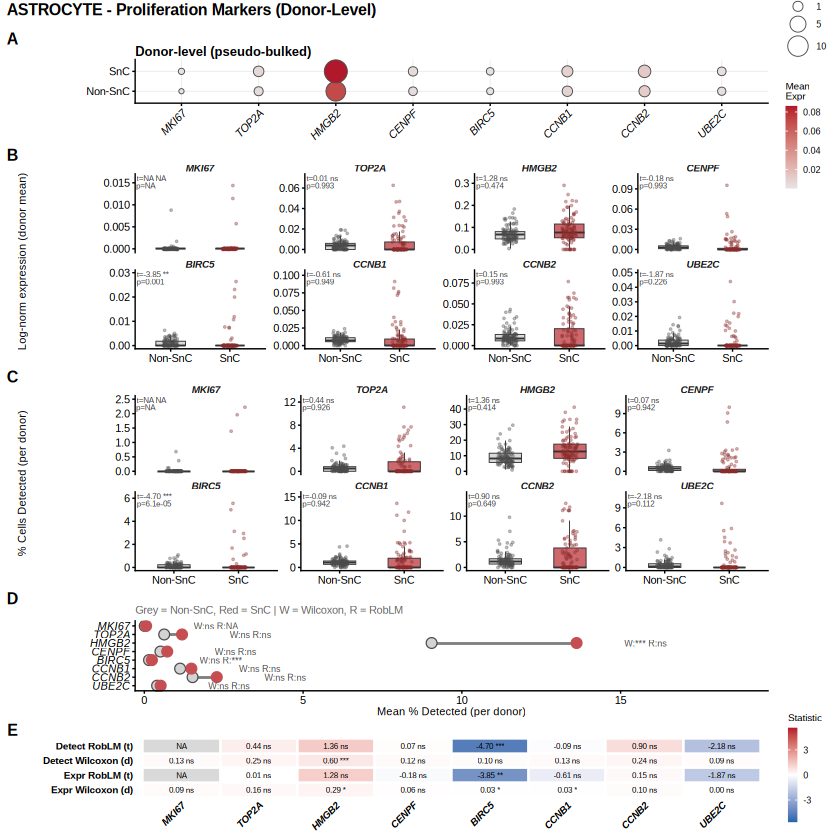

In [9]:
# ════════════════════════════════════════════════════════════════════════════════
# MODULE 09 — STEP 6: CANONICAL MARKER EXPRESSION (SnC vs Non-SnC)
# ════════════════════════════════════════════════════════════════════════════════

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("MODULE 09 — STEP 6: CANONICAL MARKER EXPRESSION\n")
cat(paste(rep("=", 80), collapse = ""), "\n")

suppressPackageStartupMessages({
    library(dplyr)
    library(tidyr)
    library(ggplot2)
    library(patchwork)
    library(robustbase)
})

select <- dplyr::select

if (!exists("obj_ct")) stop("Run Step 1 first")

# ─────────────────────────────────────────────────────────────────────────────
# PART A: DEFINE MARKERS & CHECK AVAILABILITY
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART A: Define markers & check availability\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

markers_requested <- c("MKI67", "TOP2A", "HMGB2", "CENPF", "BIRC5",
                        "CCNB1", "CCNB2", "UBE2C")

all_genes <- rownames(obj_ct)
markers_found   <- markers_requested[markers_requested %in% all_genes]
markers_missing <- markers_requested[!markers_requested %in% all_genes]

cat("  Requested:", length(markers_requested), "\n")
cat("  Found:    ", length(markers_found), "->", paste(markers_found, collapse = ", "), "\n")
if (length(markers_missing) > 0) {
    cat("  Missing:  ", length(markers_missing), "->", paste(markers_missing, collapse = ", "), "\n")
}

# ─────────────────────────────────────────────────────────────────────────────
# PART B: EXTRACT LOG-NORMALIZED EXPRESSION
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART B: Extract log-normalized expression\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

assay_to_use <- "RNA"
slot_to_use  <- "data"

expr_mat <- GetAssayData(obj_ct, assay = assay_to_use, layer = slot_to_use)
expr_mat <- expr_mat[markers_found, , drop = FALSE]

cat("  Assay:", assay_to_use, "| Slot:", slot_to_use, "\n")
cat("  Expression matrix:", nrow(expr_mat), "genes x", ncol(expr_mat), "cells\n")

md <- obj_ct@meta.data
cell_expr <- as.data.frame(t(as.matrix(expr_mat)))
cell_expr[[DONOR_COL]] <- md[[DONOR_COL]]
cell_expr[[SEN_COL]]   <- md[[SEN_COL]]

cell_expr_paired <- cell_expr %>%
    filter(.data[[DONOR_COL]] %in% paired_ids)

cat("  Cells in paired donors:", nrow(cell_expr_paired), "\n")

# ─────────────────────────────────────────────────────────────────────────────
# PART C: CELL-LEVEL DETECTION RATES
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART C: Cell-level detection rates\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

detect_cell <- data.frame(Gene = markers_found, stringsAsFactors = FALSE)

cat(sprintf("  %-8s %8s %8s %8s\n", "Gene", "Non-SnC", "SnC", "All"))
cat("  ", paste(rep("-", 38), collapse = ""), "\n")

for (g in markers_found) {
    nonsnc_d <- mean(cell_expr_paired[[g]][cell_expr_paired[[SEN_COL]] == "False"] > 0) * 100
    snc_d    <- mean(cell_expr_paired[[g]][cell_expr_paired[[SEN_COL]] == "True"] > 0) * 100
    all_d    <- mean(cell_expr_paired[[g]] > 0) * 100
    detect_cell$pct_NonSnC[detect_cell$Gene == g] <- nonsnc_d
    detect_cell$pct_SnC[detect_cell$Gene == g]    <- snc_d
    detect_cell$pct_All[detect_cell$Gene == g]    <- all_d
    cat(sprintf("  %-8s %7.1f%% %7.1f%% %7.1f%%\n", g, nonsnc_d, snc_d, all_d))
}

# ─────────────────────────────────────────────────────────────────────────────
# PART D: DONOR-LEVEL PSEUDO-BULK (EXPRESSION + DETECTION)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART D: Donor-level pseudo-bulk\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

donor_expr <- cell_expr_paired %>%
    group_by(.data[[DONOR_COL]], .data[[SEN_COL]]) %>%
    summarise(across(all_of(markers_found), mean), .groups = "drop")

donor_detect <- cell_expr_paired %>%
    group_by(.data[[DONOR_COL]], .data[[SEN_COL]]) %>%
    summarise(across(all_of(markers_found), ~ mean(.x > 0) * 100), .groups = "drop")

cat("  Donor-level expression:", nrow(donor_expr), "rows\n")
cat("  Donor-level detection:", nrow(donor_detect), "rows\n")

if (!exists("donor_meta")) {
    donor_meta <- md %>%
        filter(.data[[DONOR_COL]] %in% paired_ids) %>%
        group_by(.data[[DONOR_COL]]) %>%
        summarise(sex = first(.data[[SEX_COL]]),
                  cohort = first(.data[[COHORT_COL]]), .groups = "drop")
}
if (!exists("donor_umi")) {
    donor_umi <- md %>%
        filter(.data[[DONOR_COL]] %in% paired_ids) %>%
        group_by(.data[[DONOR_COL]], .data[[SEN_COL]]) %>%
        summarise(mean_log10_umi = mean(log10(nCount_RNA)), .groups = "drop") %>%
        pivot_wider(id_cols = all_of(DONOR_COL), names_from = all_of(SEN_COL),
                    values_from = mean_log10_umi, names_prefix = "umi_") %>%
        mutate(delta_log10_umi = umi_True - umi_False)
}

# ─────────────────────────────────────────────────────────────────────────────
# PART E1: EXPRESSION TESTING (DONOR-LEVEL, 2 TESTS)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART E1: Expression tests (donor-level)\n")
cat("  Test 1: Paired Wilcoxon (unadjusted)\n")
cat("  Test 2: Robust LM on paired diffs ~ Sex + Cohort + delta_log10_UMI\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

sig_label <- function(p) {
    ifelse(is.na(p), "NA",
    ifelse(p < 0.001, "***",
    ifelse(p < 0.01, "**",
    ifelse(p < 0.05, "*", "ns"))))
}

expr_results <- list()

for (g in markers_found) {
    cat(sprintf("  %-8s", g))

    gene_wide <- donor_expr %>%
        dplyr::select(all_of(DONOR_COL), all_of(SEN_COL), all_of(g)) %>%
        pivot_wider(id_cols = all_of(DONOR_COL),
                    names_from = all_of(SEN_COL),
                    values_from = all_of(g))

    snc_vals    <- gene_wide$`True`
    nonsnc_vals <- gene_wide$`False`
    diff_vals   <- snc_vals - nonsnc_vals

    wt <- wilcox.test(snc_vals, nonsnc_vals, paired = TRUE,
                      exact = FALSE, conf.int = TRUE)
    w_d <- mean(diff_vals) / sd(diff_vals)

    reg_df <- gene_wide %>%
        mutate(diff = `True` - `False`) %>%
        left_join(donor_meta, by = DONOR_COL) %>%
        left_join(donor_umi, by = DONOR_COL) %>%
        mutate(sex = as.factor(sex), cohort = as.factor(cohort))

    rlm_fit <- tryCatch({
        lmrob(diff ~ sex + cohort + delta_log10_umi, data = reg_df,
              setting = "KS2014")
    }, error = function(e) NULL)

    if (!is.null(rlm_fit)) {
        rc <- summary(rlm_fit)$coefficients
        r_int <- rc["(Intercept)", "Estimate"]
        r_se  <- rc["(Intercept)", "Std. Error"]
        r_t   <- rc["(Intercept)", "t value"]
        r_p   <- rc["(Intercept)", "Pr(>|t|)"]
        r_dw  <- sum(rlm_fit$rweights < 0.9)
    } else {
        r_int <- r_se <- r_t <- r_p <- r_dw <- NA
    }

    cat(sprintf(" W:p=%.1e, d=%.2f | R:int=%+.4f, t=%.2f, p=%.1e\n",
                wt$p.value, w_d,
                ifelse(is.na(r_int), NA, r_int),
                ifelse(is.na(r_t), NA, r_t),
                ifelse(is.na(r_p), NA, r_p)))

    expr_results[[g]] <- data.frame(
        Gene = g,
        mean_SnC = mean(snc_vals), mean_NonSnC = mean(nonsnc_vals),
        mean_diff = mean(diff_vals), cohens_d = w_d,
        pct_detect_SnC = detect_cell$pct_SnC[detect_cell$Gene == g],
        pct_detect_NonSnC = detect_cell$pct_NonSnC[detect_cell$Gene == g],
        wilcox_p = wt$p.value,
        rlm_intercept = r_int, rlm_SE = r_se, rlm_t = r_t, rlm_p = r_p, rlm_dw = r_dw,
        stringsAsFactors = FALSE
    )
}

expr_df <- bind_rows(expr_results)
expr_df$wilcox_p_adj <- p.adjust(expr_df$wilcox_p, method = "BH")
expr_df$rlm_p_adj    <- p.adjust(expr_df$rlm_p, method = "BH")
expr_df$wilcox_sig   <- sig_label(expr_df$wilcox_p_adj)
expr_df$rlm_sig      <- sig_label(expr_df$rlm_p_adj)

cat("\n  EXPRESSION TEST SUMMARY:\n")
cat(sprintf("  %-8s | %8s %4s | %8s %6s %4s\n",
            "Gene", "Wilcox p", "Sig", "RobLM p", "t", "Sig"))
cat("  ", paste(rep("-", 50), collapse = ""), "\n")

for (i in seq_len(nrow(expr_df))) {
    r <- expr_df[i, ]
    cat(sprintf("  %-8s | %8.1e %4s | %8.1e %+6.2f %4s\n",
                r$Gene,
                r$wilcox_p_adj, r$wilcox_sig,
                r$rlm_p_adj, r$rlm_t, r$rlm_sig))
}

# ─────────────────────────────────────────────────────────────────────────────
# PART E2: DETECTION RATE TESTING (DONOR-LEVEL, 2 TESTS)
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART E2: Detection rate tests (donor-level)\n")
cat("  Test 1: Paired Wilcoxon on % detected\n")
cat("  Test 2: Robust LM on paired detection diffs ~ Sex + Cohort + delta_log10_UMI\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

detect_results <- list()

for (g in markers_found) {
    cat(sprintf("  %-8s", g))

    det_wide <- donor_detect %>%
        dplyr::select(all_of(DONOR_COL), all_of(SEN_COL), all_of(g)) %>%
        pivot_wider(id_cols = all_of(DONOR_COL),
                    names_from = all_of(SEN_COL),
                    values_from = all_of(g))

    snc_det    <- det_wide$`True`
    nonsnc_det <- det_wide$`False`
    diff_det   <- snc_det - nonsnc_det

    wt <- wilcox.test(snc_det, nonsnc_det, paired = TRUE,
                      exact = FALSE, conf.int = TRUE)
    w_d <- mean(diff_det) / max(sd(diff_det), 1e-10)

    reg_df <- det_wide %>%
        mutate(diff = `True` - `False`) %>%
        left_join(donor_meta, by = DONOR_COL) %>%
        left_join(donor_umi, by = DONOR_COL) %>%
        mutate(sex = as.factor(sex), cohort = as.factor(cohort))

    rlm_fit <- tryCatch({
        lmrob(diff ~ sex + cohort + delta_log10_umi, data = reg_df,
              setting = "KS2014")
    }, error = function(e) NULL)

    if (!is.null(rlm_fit)) {
        rc <- summary(rlm_fit)$coefficients
        r_int <- rc["(Intercept)", "Estimate"]
        r_se  <- rc["(Intercept)", "Std. Error"]
        r_t   <- rc["(Intercept)", "t value"]
        r_p   <- rc["(Intercept)", "Pr(>|t|)"]
        r_dw  <- sum(rlm_fit$rweights < 0.9)
    } else {
        r_int <- r_se <- r_t <- r_p <- r_dw <- NA
    }

    cat(sprintf(" diff=%+.1f%% | W:p=%.1e | R:int=%+.2f, t=%.2f, p=%.1e\n",
                mean(diff_det), wt$p.value,
                ifelse(is.na(r_int), NA, r_int),
                ifelse(is.na(r_t), NA, r_t),
                ifelse(is.na(r_p), NA, r_p)))

    detect_results[[g]] <- data.frame(
        Gene = g,
        mean_SnC = mean(snc_det), mean_NonSnC = mean(nonsnc_det),
        mean_diff = mean(diff_det), cohens_d = w_d,
        n_donors_snc_nonzero = sum(snc_det > 0),
        n_donors_non_nonzero = sum(nonsnc_det > 0),
        wilcox_p = wt$p.value,
        rlm_intercept = r_int, rlm_SE = r_se, rlm_t = r_t, rlm_p = r_p, rlm_dw = r_dw,
        stringsAsFactors = FALSE
    )
}

detect_df <- bind_rows(detect_results)
detect_df$wilcox_p_adj <- p.adjust(detect_df$wilcox_p, method = "BH")
detect_df$rlm_p_adj    <- p.adjust(detect_df$rlm_p, method = "BH")
detect_df$wilcox_sig   <- sig_label(detect_df$wilcox_p_adj)
detect_df$rlm_sig      <- sig_label(detect_df$rlm_p_adj)

cat("\n  DETECTION RATE TEST SUMMARY:\n")
cat(sprintf("  %-8s %7s %7s %7s | %8s %4s | %8s %6s %4s\n",
            "Gene", "%SnC", "%Non", "Diff",
            "Wilcox p", "Sig", "RobLM p", "t", "Sig"))
cat("  ", paste(rep("-", 72), collapse = ""), "\n")

for (i in seq_len(nrow(detect_df))) {
    r <- detect_df[i, ]
    cat(sprintf("  %-8s %6.1f%% %6.1f%% %+6.1f%% | %8.1e %4s | %8.1e %+6.2f %4s\n",
                r$Gene, r$mean_SnC, r$mean_NonSnC, r$mean_diff,
                r$wilcox_p_adj, r$wilcox_sig,
                r$rlm_p_adj, r$rlm_t, r$rlm_sig))
}

# ─────────────────────────────────────────────────────────────────────────────
# PART F: VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

cat("\n", paste(rep("-", 60), collapse = ""), "\n")
cat("PART F: Visualization\n")
cat(paste(rep("-", 60), collapse = ""), "\n")

TAG_SIZE <- 9

theme_pub <- theme_classic(base_size = 7) +
    theme(
        plot.title       = element_text(face = "bold", size = 7.5, margin = margin(0, 0, 2, 0)),
        plot.subtitle    = element_text(size = 6, color = "grey40", margin = margin(0, 0, 4, 0)),
        plot.margin      = margin(2, 2, 2, 2),
        plot.tag          = element_text(face = "bold", size = TAG_SIZE),
        strip.text       = element_text(face = "bold", size = 6, margin = margin(1, 0, 1, 0)),
        strip.background = element_blank(),
        axis.title       = element_text(size = 6.5),
        axis.text        = element_text(size = 6),
        axis.line        = element_line(linewidth = 0.3),
        axis.ticks       = element_line(linewidth = 0.3),
        legend.title     = element_text(size = 5.5),
        legend.text      = element_text(size = 5),
        legend.key.size  = unit(0.25, "cm")
    )

SEN_FILL   <- c("False" = "#D3D3D3", "True" = "#C44E52")
SEN_LABELS <- c("False" = "Non-SnC", "True" = "SnC")
nrow_facet <- ifelse(length(markers_found) <= 4, 1, 2)

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1: DONOR-LEVEL PANELS
# ═══════════════════════════════════════════════════════════════════════════

cat("\n  --- Figure 1: Donor-level ---\n")

# --- Panel A: Donor-level dot plot ---

cat("  Panel A: Dot plot\n")

donor_dot_data <- donor_expr %>%
    pivot_longer(cols = all_of(markers_found), names_to = "Gene", values_to = "expr")

donor_det_data <- donor_detect %>%
    pivot_longer(cols = all_of(markers_found), names_to = "Gene", values_to = "pct_det")

donor_dot_summary <- donor_dot_data %>%
    group_by(Gene, .data[[SEN_COL]]) %>%
    summarise(mean_expr = mean(expr), .groups = "drop") %>%
    left_join(
        donor_det_data %>%
            group_by(Gene, .data[[SEN_COL]]) %>%
            summarise(mean_pct_det = mean(pct_det), .groups = "drop"),
        by = c("Gene", SEN_COL)
    ) %>%
    mutate(
        Gene      = factor(Gene, levels = markers_found),
        sen_label = factor(.data[[SEN_COL]], levels = c("False", "True"),
                           labels = c("Non-SnC", "SnC"))
    )

p_dot_donor <- ggplot(donor_dot_summary, aes(x = Gene, y = sen_label)) +
    geom_point(aes(size = mean_pct_det, fill = mean_expr),
               shape = 21, color = "grey30", stroke = 0.3) +
    scale_size_continuous(range = c(1, 6), name = "Mean %\nDetected",
                          breaks = c(1, 5, 10, 25, 50)) +
    scale_fill_gradient(low = "grey90", high = "#B2182B", name = "Mean\nExpr") +
    labs(x = NULL, y = NULL, tag = "A",
         title = "Donor-level (pseudo-bulked)") +
    theme_pub +
    theme(
        axis.text.x       = element_text(face = "italic", angle = 45, hjust = 1, size = 6),
        legend.position    = "right",
        legend.key.height  = unit(0.35, "cm"),
        legend.key.width   = unit(0.25, "cm"),
        panel.grid.major   = element_line(color = "grey92", linewidth = 0.2)
    )

cat("    Done\n")

# --- Panel B: Donor-level expression boxplots (RobLM stats) ---

cat("  Panel B: Expression boxplots (RobLM stats)\n")

donor_long <- donor_expr %>%
    pivot_longer(cols = all_of(markers_found), names_to = "Gene", values_to = "expr") %>%
    mutate(
        Gene      = factor(Gene, levels = markers_found),
        sen_label = factor(.data[[SEN_COL]], levels = c("False", "True"))
    )

stats_labels_expr <- expr_df %>%
    mutate(
        Gene = factor(Gene, levels = markers_found),
        label = paste0(
            "t=", ifelse(is.na(rlm_t), "NA", sprintf("%.2f", rlm_t)), " ", rlm_sig, "\n",
            "p=", ifelse(is.na(rlm_p_adj), "NA",
                  ifelse(rlm_p_adj < 0.001, sprintf("%.1e", rlm_p_adj),
                         sprintf("%.3f", rlm_p_adj)))
        )
    )

p_box_donor <- ggplot(donor_long, aes(x = sen_label, y = expr, fill = sen_label)) +
    geom_boxplot(width = 0.5, outlier.shape = NA, linewidth = 0.2, alpha = 0.85) +
    geom_jitter(aes(color = sen_label), width = 0.12, size = 0.3, alpha = 0.35,
                show.legend = FALSE) +
    scale_color_manual(values = c("False" = "grey30", "True" = "#8B2C2C")) +
    facet_wrap(~Gene, nrow = nrow_facet, scales = "free_y") +
    scale_fill_manual(values = SEN_FILL, labels = SEN_LABELS, name = NULL) +
    scale_x_discrete(labels = SEN_LABELS) +
    scale_y_continuous(expand = expansion(mult = c(0.05, 0.18))) +
    geom_text(data = stats_labels_expr,
              aes(x = -Inf, y = Inf, label = label),
              inherit.aes = FALSE,
              hjust = -0.05, vjust = 1.1, size = 1.5, color = "grey25",
              lineheight = 0.85) +
    labs(x = NULL, y = "Log-norm expression (donor mean)", tag = "B") +
    theme_pub +
    theme(legend.position = "none",
          panel.spacing   = unit(0.12, "cm"),
          strip.text      = element_text(face = "bold.italic", size = 5.5))

cat("    Done\n")

# --- Panel C: Donor-level detection boxplots (RobLM stats) ---

cat("  Panel C: Detection boxplots (RobLM stats)\n")

donor_det_long <- donor_detect %>%
    pivot_longer(cols = all_of(markers_found), names_to = "Gene", values_to = "pct_det") %>%
    mutate(
        Gene      = factor(Gene, levels = markers_found),
        sen_label = factor(.data[[SEN_COL]], levels = c("False", "True"))
    )

stats_labels_det <- detect_df %>%
    mutate(
        Gene = factor(Gene, levels = markers_found),
        label = paste0(
            "t=", ifelse(is.na(rlm_t), "NA", sprintf("%.2f", rlm_t)), " ", rlm_sig, "\n",
            "p=", ifelse(is.na(rlm_p_adj), "NA",
                  ifelse(rlm_p_adj < 0.001, sprintf("%.1e", rlm_p_adj),
                         sprintf("%.3f", rlm_p_adj)))
        )
    )

p_detect_donor <- ggplot(donor_det_long, aes(x = sen_label, y = pct_det, fill = sen_label)) +
    geom_boxplot(width = 0.5, outlier.shape = NA, linewidth = 0.2, alpha = 0.85) +
    geom_jitter(aes(color = sen_label), width = 0.12, size = 0.3, alpha = 0.35,
                show.legend = FALSE) +
    scale_color_manual(values = c("False" = "grey30", "True" = "#8B2C2C")) +
    facet_wrap(~Gene, nrow = nrow_facet, scales = "free_y") +
    scale_fill_manual(values = SEN_FILL, labels = SEN_LABELS, name = NULL) +
    scale_x_discrete(labels = SEN_LABELS) +
    scale_y_continuous(expand = expansion(mult = c(0.05, 0.18))) +
    geom_text(data = stats_labels_det,
              aes(x = -Inf, y = Inf, label = label),
              inherit.aes = FALSE,
              hjust = -0.05, vjust = 1.1, size = 1.5, color = "grey25",
              lineheight = 0.85) +
    labs(x = NULL, y = "% Cells Detected (per donor)", tag = "C") +
    theme_pub +
    theme(legend.position = "none",
          panel.spacing   = unit(0.12, "cm"),
          strip.text      = element_text(face = "bold.italic", size = 5.5))

cat("    Done\n")

# --- Panel D: Dumbbell plot ---

cat("  Panel D: Dumbbell plot\n")

dumbbell_df <- detect_df %>%
    mutate(Gene = factor(Gene, levels = rev(markers_found)))

dumbbell_df$sig_label <- paste0("W:", dumbbell_df$wilcox_sig,
                                " R:", dumbbell_df$rlm_sig)

p_dumbbell <- ggplot(dumbbell_df) +
    geom_segment(aes(x = mean_NonSnC, xend = mean_SnC,
                     y = Gene, yend = Gene),
                 color = "grey50", linewidth = 0.6) +
    geom_point(aes(x = mean_NonSnC, y = Gene),
               size = 2.5, stroke = 0.4, shape = 21,
               color = "grey30", fill = "#D3D3D3") +
    geom_point(aes(x = mean_SnC, y = Gene),
               size = 2.5, stroke = 0.4, shape = 21,
               color = "#C44E52", fill = "#C44E52") +
    geom_text(aes(x = pmax(mean_SnC, mean_NonSnC) + 1.5, y = Gene,
                  label = sig_label),
              size = 1.8, hjust = 0, color = "grey30") +
    scale_x_continuous(expand = expansion(mult = c(0.02, 0.3))) +
    labs(x = "Mean % Detected (per donor)",
         y = NULL, tag = "D",
         subtitle = "Grey = Non-SnC, Red = SnC | W = Wilcoxon, R = RobLM") +
    theme_pub +
    theme(axis.text.y = element_text(face = "italic", size = 6.5))

cat("    Done\n")

# --- Panel E: Effect size heatmap (4 rows: 2 tests x 2 outcomes) ---

cat("  Panel E: Effect size heatmap\n")

heat_all <- data.frame(
    Gene = factor(rep(markers_found, 4), levels = markers_found),
    Test = factor(rep(c("Expr Wilcoxon (d)", "Expr RobLM (t)",
                        "Detect Wilcoxon (d)", "Detect RobLM (t)"),
                      each = length(markers_found)),
                  levels = c("Expr Wilcoxon (d)", "Expr RobLM (t)",
                             "Detect Wilcoxon (d)", "Detect RobLM (t)")),
    value = c(expr_df$cohens_d, expr_df$rlm_t,
              detect_df$cohens_d, detect_df$rlm_t),
    sig   = c(expr_df$wilcox_sig, expr_df$rlm_sig,
              detect_df$wilcox_sig, detect_df$rlm_sig)
)

heat_all$label <- ifelse(is.na(heat_all$value), "NA",
                         sprintf("%.2f %s", heat_all$value, heat_all$sig))
all_lim <- max(abs(heat_all$value), na.rm = TRUE) * 1.2

p_heat_all <- ggplot(heat_all, aes(x = Gene, y = Test, fill = value)) +
    geom_tile(color = "white", linewidth = 0.5) +
    geom_text(aes(label = label), size = 1.5) +
    scale_fill_gradient2(
        low = "#2166AC", mid = "white", high = "#B2182B",
        midpoint = 0, limits = c(-all_lim, all_lim), name = "Statistic",
        na.value = "grey85"
    ) +
    labs(x = NULL, y = NULL, tag = "E") +
    theme_pub +
    theme(
        panel.grid        = element_blank(),
        axis.line         = element_blank(),
        axis.ticks        = element_blank(),
        axis.text.x       = element_text(face = "bold.italic", size = 5.5, angle = 45, hjust = 1),
        axis.text.y       = element_text(face = "bold", size = 5.5),
        legend.position   = "right",
        legend.key.height = unit(0.4, "cm"),
        legend.key.width  = unit(0.2, "cm")
    )

cat("    Done\n")

# Combine donor-level
p_donor_combined <- (p_dot_donor) /
                    (p_box_donor) /
                    (p_detect_donor) /
                    (p_dumbbell) /
                    (p_heat_all) +
    plot_layout(heights = c(0.25, 1, 1, 0.4, 0.35)) +
    plot_annotation(
        title = paste0(toupper(CELL_TYPE), " - Proliferation Markers (Donor-Level)"),
        theme = theme(
            plot.title  = element_text(face = "bold", size = 9),
            plot.margin = margin(2, 2, 2, 2)
        )
    )

cat("    Done: Donor-level combined\n")

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2: CELL-LEVEL PANELS (DESCRIPTIVE ONLY)
# ═══════════════════════════════════════════════════════════════════════════

cat("\n  --- Figure 2: Cell-level (descriptive) ---\n")

# --- Panel A: Cell-level dot plot ---

cat("  Panel A: Cell-level dot plot\n")

cell_dot_data <- cell_expr_paired %>%
    pivot_longer(cols = all_of(markers_found), names_to = "Gene", values_to = "expr") %>%
    group_by(Gene, .data[[SEN_COL]]) %>%
    summarise(
        pct_detect = mean(expr > 0) * 100,
        mean_expr  = mean(expr[expr > 0]),
        .groups    = "drop"
    ) %>%
    mutate(
        Gene      = factor(Gene, levels = markers_found),
        sen_label = factor(.data[[SEN_COL]], levels = c("False", "True"),
                           labels = c("Non-SnC", "SnC"))
    )

cell_dot_data$mean_expr[is.nan(cell_dot_data$mean_expr)] <- 0

p_dot_cell <- ggplot(cell_dot_data, aes(x = Gene, y = sen_label)) +
    geom_point(aes(size = pct_detect, fill = mean_expr),
               shape = 21, color = "grey30", stroke = 0.3) +
    scale_size_continuous(range = c(1, 6), name = "% Detected",
                          breaks = c(1, 5, 10, 25, 50)) +
    scale_fill_gradient(low = "grey90", high = "#B2182B", name = "Mean Expr\n(detected)") +
    labs(x = NULL, y = NULL, tag = "A",
         title = "Cell-level (descriptive)") +
    theme_pub +
    theme(
        axis.text.x       = element_text(face = "italic", angle = 45, hjust = 1, size = 6),
        legend.position    = "right",
        legend.key.height  = unit(0.35, "cm"),
        legend.key.width   = unit(0.25, "cm"),
        panel.grid.major   = element_line(color = "grey92", linewidth = 0.2)
    )

cat("    Done\n")

# --- Panel B: Cell-level violin plots ---

cat("  Panel B: Cell-level violins\n")

cell_long <- cell_expr_paired %>%
    pivot_longer(cols = all_of(markers_found), names_to = "Gene", values_to = "expr") %>%
    mutate(
        Gene      = factor(Gene, levels = markers_found),
        sen_label = factor(.data[[SEN_COL]], levels = c("False", "True"))
    )

p_violin_cell <- ggplot(cell_long, aes(x = sen_label, y = expr, fill = sen_label)) +
    geom_violin(scale = "width", linewidth = 0.2, alpha = 0.85,
                trim = TRUE, adjust = 1.5) +
    geom_boxplot(width = 0.15, outlier.shape = NA, linewidth = 0.2,
                 fill = "white", alpha = 0.6) +
    facet_wrap(~Gene, nrow = nrow_facet, scales = "free_y") +
    scale_fill_manual(values = SEN_FILL, labels = SEN_LABELS, name = NULL) +
    scale_x_discrete(labels = SEN_LABELS) +
    labs(x = NULL, y = "Log-norm expression (cell-level)", tag = "B") +
    theme_pub +
    theme(legend.position = "none",
          panel.spacing   = unit(0.12, "cm"),
          strip.text      = element_text(face = "bold.italic", size = 5.5))

cat("    Done\n")

# --- Panel C: Cell-level detection bar plot ---

cat("  Panel C: Cell-level detection bars\n")

detect_cell_long <- detect_cell %>%
    pivot_longer(cols = c(pct_NonSnC, pct_SnC), names_to = "Status", values_to = "pct") %>%
    mutate(
        Gene   = factor(Gene, levels = markers_found),
        Status = factor(ifelse(Status == "pct_SnC", "SnC", "Non-SnC"),
                        levels = c("Non-SnC", "SnC"))
    )

p_detect_cell <- ggplot(detect_cell_long, aes(x = Gene, y = pct, fill = Status)) +
    geom_col(position = position_dodge(width = 0.7), width = 0.6,
             color = "grey30", linewidth = 0.2) +
    scale_fill_manual(values = c("Non-SnC" = "#D3D3D3", "SnC" = "#C44E52"), name = NULL) +
    labs(x = NULL, y = "% Cells Detected", tag = "C") +
    theme_pub +
    theme(
        axis.text.x     = element_text(face = "italic", angle = 45, hjust = 1, size = 6),
        legend.position = "top",
        legend.key.size = unit(0.3, "cm")
    )

cat("    Done\n")

# Combine cell-level
p_cell_combined <- (p_dot_cell) /
                   (p_violin_cell) /
                   (p_detect_cell) +
    plot_layout(heights = c(0.3, 1, 0.45)) +
    plot_annotation(
        title = paste0(toupper(CELL_TYPE), " - Proliferation Markers (Cell-Level)"),
        theme = theme(
            plot.title  = element_text(face = "bold", size = 9),
            plot.margin = margin(2, 2, 2, 2)
        )
    )

cat("    Done: Cell-level combined\n")

# ─────────────────────────────────────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────────────────────────────────────

cat("\nSaving\n")

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_marker_donor_combined.svg")),
       p_donor_combined, width = 6, height = 12, dpi = 300)
cat("  Done:", paste0(CELL_TYPE, "_marker_donor_combined.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_marker_cell_combined.svg")),
       p_cell_combined, width = 6, height = 7, dpi = 300)
cat("  Done:", paste0(CELL_TYPE, "_marker_cell_combined.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_marker_donor_boxplot.svg")),
       p_box_donor, width = 5.5, height = 3.5, dpi = 300)
cat("  Done:", paste0(CELL_TYPE, "_marker_donor_boxplot.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_marker_detect_boxplot.svg")),
       p_detect_donor, width = 5.5, height = 3.5, dpi = 300)
cat("  Done:", paste0(CELL_TYPE, "_marker_detect_boxplot.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_marker_cell_violin.svg")),
       p_violin_cell, width = 5.5, height = 3.5, dpi = 300)
cat("  Done:", paste0(CELL_TYPE, "_marker_cell_violin.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_marker_dumbbell.svg")),
       p_dumbbell, width = 4.5, height = 2.5, dpi = 300)
cat("  Done:", paste0(CELL_TYPE, "_marker_dumbbell.svg\n"))

ggsave(file.path(FIGURES_DIR, paste0(CELL_TYPE, "_marker_effect_heatmap.svg")),
       p_heat_all, width = 5.5, height = 2, dpi = 300)
cat("  Done:", paste0(CELL_TYPE, "_marker_effect_heatmap.svg\n"))

print(p_donor_combined)

write.csv(expr_df,
          file.path(RESULTS_DIR, paste0(CELL_TYPE, "_marker_expr_tests.csv")),
          row.names = FALSE)
cat("  Done:", paste0(CELL_TYPE, "_marker_expr_tests.csv\n"))

write.csv(detect_df,
          file.path(RESULTS_DIR, paste0(CELL_TYPE, "_marker_detect_tests.csv")),
          row.names = FALSE)
cat("  Done:", paste0(CELL_TYPE, "_marker_detect_tests.csv\n"))

write.csv(detect_cell,
          file.path(RESULTS_DIR, paste0(CELL_TYPE, "_marker_detection_cell.csv")),
          row.names = FALSE)
cat("  Done:", paste0(CELL_TYPE, "_marker_detection_cell.csv\n"))

cat("\n", paste(rep("=", 80), collapse = ""), "\n")
cat("STEP 6 COMPLETE\n")
cat(paste(rep("=", 80), collapse = ""), "\n")
cat("  Markers tested:           ", length(markers_found), "\n")
cat("  Expr Wilcoxon sig (FDR):  ", sum(expr_df$wilcox_p_adj < 0.05), "/", nrow(expr_df), "\n")
cat("  Expr RobLM sig (FDR):     ", sum(expr_df$rlm_p_adj < 0.05, na.rm = TRUE), "/", nrow(expr_df), "\n")
cat("  Detect Wilcoxon sig (FDR):", sum(detect_df$wilcox_p_adj < 0.05), "/", nrow(detect_df), "\n")
cat("  Detect RobLM sig (FDR):   ", sum(detect_df$rlm_p_adj < 0.05, na.rm = TRUE), "/", nrow(detect_df), "\n")
cat("  Figures:                  ", FIGURES_DIR, "\n")
cat("  Results:                  ", RESULTS_DIR, "\n")
cat(paste(rep("=", 80), collapse = ""), "\n")